### Defining Trial Activation & Conversion Drivers for a Workforce Management SaaS Platform

### Introduction

Splendor Analytics offers a 30-day free trial for organisations using its workforce management platform. However, the company lacks clarity on what defines a “successful” trial experience and which user behaviors drive conversion to paid plans.

This project analyzes behavioral event data to:

- Identify key engagement patterns

- Define trial activation criteria

- Build data models for scalable tracking

- Generate product insights for decision-making

### Project Objectives

1. Clean and prepare raw event data for analysis

2. Identify behaviors that correlate with conversion

3. Define measurable Trial Goals (Activation Criteria)

4. Build SQL models:

    - Trial Goals Table

    - Trial Activation Table

5. Generate product insights:

    - Conversion drivers

    - Engagement patterns

    - Feature adoption

### Importing Libraries and Loading the Raw CSV dataset of behavioural events

In [3]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn", "scipy", "statsmodels", "-q"], check=True)

CompletedProcess(args=['pip', 'install', 'scikit-learn', 'scipy', 'statsmodels', '-q'], returncode=0)

In [5]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# File paths — relative to notebook location 

# Set working directory to your project folder
os.chdir(r"C:\Users\DELL\Desktop\Data Analytics Projects\splendor_analytics")

# Confirm it worked
print(f"Working directory: {os.getcwd()}")



Working directory: C:\Users\DELL\Desktop\Data Analytics Projects\splendor_analytics


In [8]:
import os

# List all files in my project folder
for file in os.listdir(os.getcwd()):
    print(file)

DA_task.csv.csv
outputs
README.md.txt
requirements.txt
Splendor_notebook.ipynb
task2_sql_models.sql


In [9]:
# define file paths

RAW_DATA    = "DA_task.csv"
OUTPUT_PATH = "outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)
print("✓ Setup complete")

✓ Setup complete


In [10]:
# Loading the raw dataset and initial inspection

df = pd.read_csv(RAW_DATA)
print(f"✓ Data loaded: {df.shape}")

✓ Data loaded: (170526, 7)


In [11]:
df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [12]:
print(f"df shape     : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print(f"Nulls:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df shape     : (170526, 7)
Columns       : ['ORGANIZATION_ID', 'ACTIVITY_NAME', 'TIMESTAMP', 'CONVERTED', 'CONVERTED_AT', 'TRIAL_START', 'TRIAL_END']
Nulls:
ORGANIZATION_ID         0
ACTIVITY_NAME           0
TIMESTAMP               0
CONVERTED               0
CONVERTED_AT       136291
TRIAL_START             0
TRIAL_END               0
dtype: int64

Duplicate rows: 67631


- The dataset is event-heavy but highly duplicated (67,631 duplicates ≈ ~40%), meaning deduplication is critical before any analysis to avoid biased results.

- A large portion of CONVERTED_AT is missing (136,291 rows), which is expected for non-converted organizations, but must be handled carefully when creating conversion-related features.

- All key columns are present with no missing IDs, timestamps, or activity names, indicating good structural integrity, but still requires validation (e.g., date consistency within trial period).

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170526 entries, 0 to 170525
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   ORGANIZATION_ID  170526 non-null  str  
 1   ACTIVITY_NAME    170526 non-null  str  
 2   TIMESTAMP        170526 non-null  str  
 3   CONVERTED        170526 non-null  bool 
 4   CONVERTED_AT     34235 non-null   str  
 5   TRIAL_START      170526 non-null  str  
 6   TRIAL_END        170526 non-null  str  
dtypes: bool(1), str(6)
memory usage: 29.1 MB


### Task 1: Data Cleaning, EDA & Conversion Driver Analysis

Normalize column names

In [13]:
# Normalise column names

df.columns = df.columns.str.lower()

df.head(2)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


Parse datetime columns

In [14]:

# Fix data type:

for col in ["timestamp", "converted_at", "trial_start", "trial_end"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [15]:
df.head(2)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39


### Remove exact duplicate rows (same org + activity + timestamp)


In [16]:
# Remove exact duplicate rows (same org + activity + timestamp)

df = df.drop_duplicates(subset=["organization_id", "activity_name", "timestamp"])

print(f"After dedup   : {df.shape}")

After dedup   : (102895, 7)


### Drop events outside trial window (± 1 min tolerance)

In [17]:
# Drop events outside trial window (± 1 min tolerance)

mask_in_window = (
    (df["timestamp"] >= df["trial_start"] - pd.Timedelta("1min")) &
    (df["timestamp"] <= df["trial_end"]   + pd.Timedelta("1min"))
)
df = df[mask_in_window]
print(f"After window  : {df.shape[0]} rows")

After window  : 102895 rows


In [18]:
# Validate converted_at logic
# converted=True must have a non-null converted_at inside the trial window

bad_converted = (df["converted"] == True) & (df["converted_at"].isna())
print(f"Converted=True with null converted_at: {bad_converted.sum()}")

Converted=True with null converted_at: 0


The missing values in converted_at are expected and represent organisations that did not convert during the trial period. Instead of imputing or removing these values, they were preserved to maintain the integrity of conversion analysis. 

### Create Derived Features

In [19]:
# Days since trial start
df['days_from_start'] = (df['timestamp'] - df['trial_start']).dt.days

# Trial duration
df['trial_length'] = (df['trial_end'] - df['trial_start']).dt.days

# Before/after conversion
df['before_conversion'] = df['timestamp'] <= df['converted_at']

In [20]:
df.head(2)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,days_from_start,trial_length,before_conversion
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False


In [21]:
# Checking Unique values in the activity_name column

df['activity_name'].unique()

<ArrowStringArray>
[              'Scheduling.Shift.Created',
     'Scheduling.Shift.AssignmentChanged',
          'Communication.Message.Created',
                 'Mobile.Schedule.Loaded',
                'Absence.Request.Created',
               'Absence.Request.Approved',
            'Scheduling.Availability.Set',
 'Scheduling.Template.ApplyModal.Applied',
      'PunchClockStartNote.Add.Completed',
                   'PunchClock.PunchedIn',
                'PunchClock.Entry.Edited',
              'Scheduling.Shift.Approved',
               'ShiftDetails.View.Opened',
               'Absence.Request.Rejected',
    'Scheduling.OpenShiftRequest.Created',
           'Scheduling.ShiftSwap.Created',
        'PunchClockEndNote.Add.Completed',
                  'PunchClock.PunchedOut',
  'Integration.Xero.PayrollExport.Synced',
       'Timesheets.BulkApprove.Confirmed',
       'Scheduling.ShiftHandover.Created',
      'Scheduling.ShiftHandover.Accepted',
                'Revenue.Budgets.Cr

The **activity_name** column contains granular event-level interactions performed by organisations during their trial period. While detailed, these raw event names are inconsistent in structure and overly fragmented, making direct analysis noisy and less interpretable.

To address this, the column will be cleaned and transformed in three stages:


- Normalization: Merge similar or duplicate actions (e.g., different “view” or “decision” events) into unified labels.

- Feature Transformation: Map activities into higher-level product categories (e.g., scheduling, payroll, communication) and action types (e.g., create, approve, view) to better reflect user behavior and product usage.

This transformation reduces dimensionality, improves interpretability, and enables more meaningful analysis of engagement patterns and conversion drivers.

### Adding a Canonical Name Column

In [22]:
# Adding a Canonical Name Column
# some activities listed as a single entry covering two event names(same action)
# are grouped under one canonical name for analysis.

# Map each raw activity to the clean label from the activity name description list

activity_canonical = {
    # Scheduling
    "Scheduling.Availability.Set":               "Set Availability",
    "Scheduling.Shift.Created":                  "Shift Created",
    "Scheduling.Shift.AssignmentChanged":        "Shift Assignment Changed",
    "Scheduling.Template.ApplyModal.Applied":    "Template Applied",
    "Scheduling.ShiftSwap.Created":              "Shift Swap Requested",
    "Scheduling.ShiftSwap.Accepted":             "Shift Swap Accepted",
    "Scheduling.ShiftHandover.Created":          "Shift Handover Requested",
    "Scheduling.ShiftHandover.Accepted":         "Shift Handover Accepted",
    "Scheduling.OpenShiftRequest.Created":       "Open Shift Requested",
    "Scheduling.OpenShiftRequest.Approved":      "Open Shift Approved",
    "Scheduling.Shift.Approved":                 "Shift Approved",

    # Viewing
    "Mobile.Schedule.Loaded":                    "Schedule Viewed",
    "Shift.View.Opened":                         "Shift Details Viewed",
    "ShiftDetails.View.Opened":                  "Shift Details Viewed",   # ← merged

    # Absence
    "Absence.Request.Created":                   "Absence Requested",
    "Absence.Request.Approved":                  "Absence Approved/Rejected",
    "Absence.Request.Rejected":                  "Absence Approved/Rejected", # ← merged

    # PunchClock
    "PunchClock.PunchedIn":                      "Punched In/Out",  # ← merged
    "PunchClock.PunchedOut":                     "Punched In/Out",  # ← merged
    "Break.Activate.Started":                    "Break Started/Finished",  # ← merged
    "Break.Activate.Finished":                   "Break Started/Finished",  # ← merged
    "PunchClockStartNote.Add.Completed":         "Punch-In Note Added",
    "PunchClockEndNote.Add.Completed":           "Punch-Out Note Added",
    "PunchClock.Entry.Edited":                   "Clock Entry Edited",

    # Approval & Payroll
    "Timesheets.BulkApprove.Confirmed":          "Timesheets Bulk Approved",
    "Integration.Xero.PayrollExport.Synced":     "Payroll Synced (Xero)",
    "Revenue.Budgets.Created":                   "Budget Created",

    # Communication
    "Communication.Message.Created":             "Message Sent",
}

df["activity_canonical"] = df["activity_name"].map(activity_canonical)

In [23]:
df['activity_canonical'].unique()

<ArrowStringArray>
[            'Shift Created',  'Shift Assignment Changed',
              'Message Sent',           'Schedule Viewed',
         'Absence Requested', 'Absence Approved/Rejected',
          'Set Availability',          'Template Applied',
       'Punch-In Note Added',            'Punched In/Out',
        'Clock Entry Edited',            'Shift Approved',
      'Shift Details Viewed',      'Open Shift Requested',
      'Shift Swap Requested',      'Punch-Out Note Added',
     'Payroll Synced (Xero)',  'Timesheets Bulk Approved',
  'Shift Handover Requested',   'Shift Handover Accepted',
            'Budget Created',    'Break Started/Finished',
       'Open Shift Approved',       'Shift Swap Accepted']
Length: 24, dtype: str

In [24]:
df.head(2)

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,days_from_start,trial_length,before_conversion,activity_canonical
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created


### Create Activity Categories 

We'll create a lookup dictionary that maps each raw activity prefix to a clean product category. It acts as a translation table, the keys are the raw prefixes, the values are the category labels we want to assign.

In [25]:

categorize_activity = {
    "Scheduling":          "Scheduling",
    "Mobile":              "Scheduling",        # mobile schedule view = scheduling feature
    "Shift":               "Scheduling",        # Shift.View.Opened
    "ShiftDetails":        "Scheduling",        # ShiftDetails.View.Opened
    "Absence":             "Absence",
    "PunchClock":          "Time Tracking",
    "PunchClockStartNote": "Time Tracking",     # ← fix grouping
    "PunchClockEndNote":   "Time Tracking",     # ← fix grouping
    "Break":               "Time Tracking",
    "Timesheets":          "Payroll",
    "Integration":         "Payroll",
    "Revenue":             "Revenue & Budgeting",   # ← its own group
    "Communication":       "Communication",
}

df["activity_category"] = df["activity_name"].str.split(".").str[0].map(categorize_activity)

In [26]:
# Confirm the activity_category

df.head()

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end,days_from_start,trial_length,before_conversion,activity_canonical,activity_category
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created,Scheduling
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created,Scheduling
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created,Scheduling
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created,Scheduling
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,0,30,False,Shift Created,Scheduling


In [27]:
print(f"\nFinal clean shape: {df.shape}")
print(f"Unique orgs      : {df['organization_id'].nunique()}")
print(f"Unique activities: {df['activity_name'].nunique()}")



Final clean shape: (102895, 12)
Unique orgs      : 966
Unique activities: 28


In [28]:
df.to_csv(f"{OUTPUT_PATH}/clean_events.csv", index=False)
print("Saved → splendor_analytics/outputs/clean_events.csv")

Saved → splendor_analytics/outputs/clean_events.csv


### Organization Level Feature Table

In [29]:
# One row per organization with activity counts + metadata
org_meta = (
    df.drop_duplicates("organization_id")
    [["organization_id", "converted", "converted_at", "trial_start", "trial_end", "trial_length"]]
)
 
# Pivot: count of each activity per organization
activity_counts = (
    df.groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)
)

# Aggregate engagement metrics
agg = df.groupby("organization_id").agg(
    total_events        = ("activity_name", "count"),
    distinct_activities = ("activity_name", "nunique"),
    distinct_category   = ("activity_category", "nunique"),
    active_days         = ("days_from_start", lambda x: x.astype(int).nunique()),
    first_event_day     = ("days_from_start", "min"),
    last_event_day      = ("days_from_start", "max"),
).reset_index()



 
orgs = org_meta.merge(agg, on="organization_id").merge(activity_counts, on="organization_id")
 
# Time-to-convert (days from trial_start)
orgs["days_to_convert"] = (orgs["converted_at"] - orgs["trial_start"]).dt.total_seconds() / 86400
 
print(f"Org feature table: {orgs.shape}")

Org feature table: (966, 41)


In [30]:
orgs.to_csv(f"{OUTPUT_PATH}/org_features.csv", index=False)

In [31]:
orgs

,organization_id,converted,converted_at,trial_start,trial_end,trial_length,total_events,distinct_activities,distinct_category,active_days,...,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed,days_to_convert
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,30,1004,14,4,11,...,576,0,0,0,0,10,0,1,0,NaN
1,00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36,30,6,4,2,1,...,1,0,0,0,0,0,0,0,0,NaN
2,007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07,30,5,2,2,2,...,0,0,0,0,0,0,0,0,0,NaN
3,00d6461845d0042b929379c263e9edef,False,NaT,2024-03-05 02:57:05,2024-04-04 02:57:05,30,2,2,2,1,...,1,0,0,0,0,0,0,0,0,NaN
4,00d812389a3cffdbf014ba194cbe922e,False,NaT,2024-03-13 22:13:10,2024-04-12 22:13:10,30,586,6,3,21,...,157,0,0,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,4e44f506184abb41230dca9183e0dfde,True,2024-02-03 15:12:28,2024-01-15 15:09:35,2024-02-14 15:09:35,30,107,4,2,9,...,24,0,0,0,0,0,0,0,0,19.002002
962,4e76bb8e72c66ac1020407778635938f,False,NaT,2024-01-23 12:48:57,2024-02-22 12:48:57,30,137,3,1,1,...,93,0,0,0,0,0,0,0,0,NaN
963,4e7e4c7bd153b3e8728e7be9e717071b,False,NaT,2024-03-11 12:47:05,2024-04-10 12:47:05,30,7,1,1,1,...,7,0,0,0,0,0,0,0,0,NaN
964,4e900f739ad1a3cc11c0bc2ad85db6ff,False,NaT,2024-02-08 08:18:17,2024-03-09 08:18:17,30,84,1,1,1,...,84,0,0,0,0,0,0,0,0,NaN


Organisation-Level Feature Table

The raw event log contains one row per activity event, which is not suitable for conversion analysis since the target variable (converted) is measured at the organisation level. The data is therefore reshaped so that each organisation is represented by a single row.

Key points:

- One row per organisation (966 rows, collapsed from 102,895 events)

- Activity counts: Each activity is pivoted into its own column showing how many times each organisation performed it

- Engagement metrics: Derived fields like total_events, distinct_activities, and active_days capture trial engagement depth

- Foundation: All downstream analyses such as conversion driver analysis, trial goal definition, and product metrics will be built on top of this table


In [32]:


# Styling

PURPLE   = "#6C3FC8"
LAVENDER = "#A78BFA"
MINT     = "#34D399"
CORAL    = "#F87171"
AMBER    = "#FBBF24"
DARK     = "#1E1B2E"
LIGHT    = "#F3F0FF"
GRAY     = "#6B7280"
 
plt.rcParams.update({
    "figure.facecolor": DARK,
    "axes.facecolor":   DARK,
    "axes.edgecolor":   "#3D3557",
    "axes.labelcolor":  "white",
    "xtick.color":      GRAY,
    "ytick.color":      GRAY,
    "text.color":       "white",
    "grid.color":       "#2D2A45",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "figure.dpi":       130,
})

### Exploratory Data Analysis (EDA)

1. Conversion Rate

What percentage of trial organisations convert to paid customers?

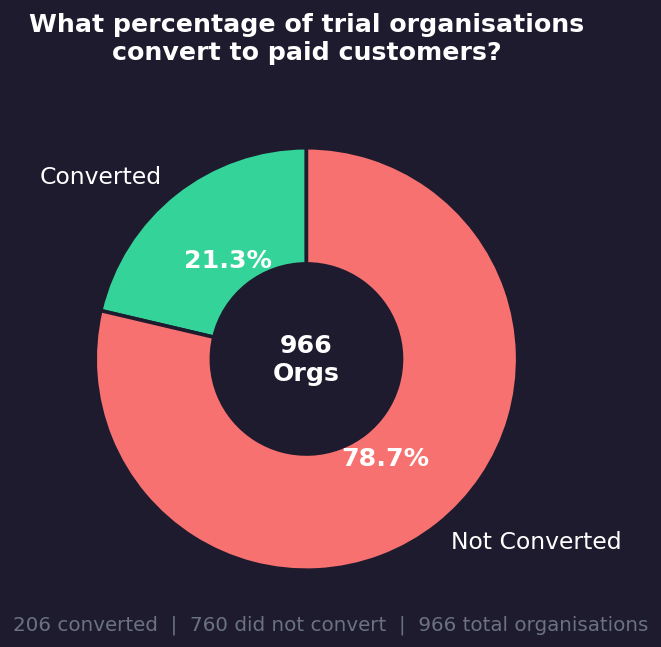

In [33]:
# What percentage of trial organisations convert to paid customers? 

# Get one row per organisation
org_conversion = df.drop_duplicates("organization_id")[["organization_id", "converted"]]

# Calculate counts and percentages
total     = len(org_conversion)
converted = org_conversion["converted"].sum()
not_conv  = total - converted
conv_pct  = converted / total * 100
not_pct   = not_conv  / total * 100

# Plot 
fig, ax = plt.subplots(figsize=(5, 5), facecolor=DARK)
ax.set_facecolor(DARK)

sizes  = [conv_pct, not_pct]
labels = ["Converted", "Not Converted"]
colors = [MINT, CORAL]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": DARK, "linewidth": 2},
    textprops={"color": "white", "fontsize": 13}
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight("bold")

# Add counts as annotation in the centre
ax.text(0, 0, f"{total}\nOrgs", ha="center", va="center",
        fontsize=14, fontweight="bold", color="white")

ax.set_title("What percentage of trial organisations\nconvert to paid customers?",
             fontsize=14, fontweight="bold", color="white", pad=20)

# Add a text summary below the chart
fig.text(0.5, 0.02,
         f"{converted} converted  |  {not_conv} did not convert  |  {total} total organisations",
         ha="center", fontsize=11, color=GRAY)

plt.tight_layout()
plt.show()

### 2. How long does it take organisations to convert?

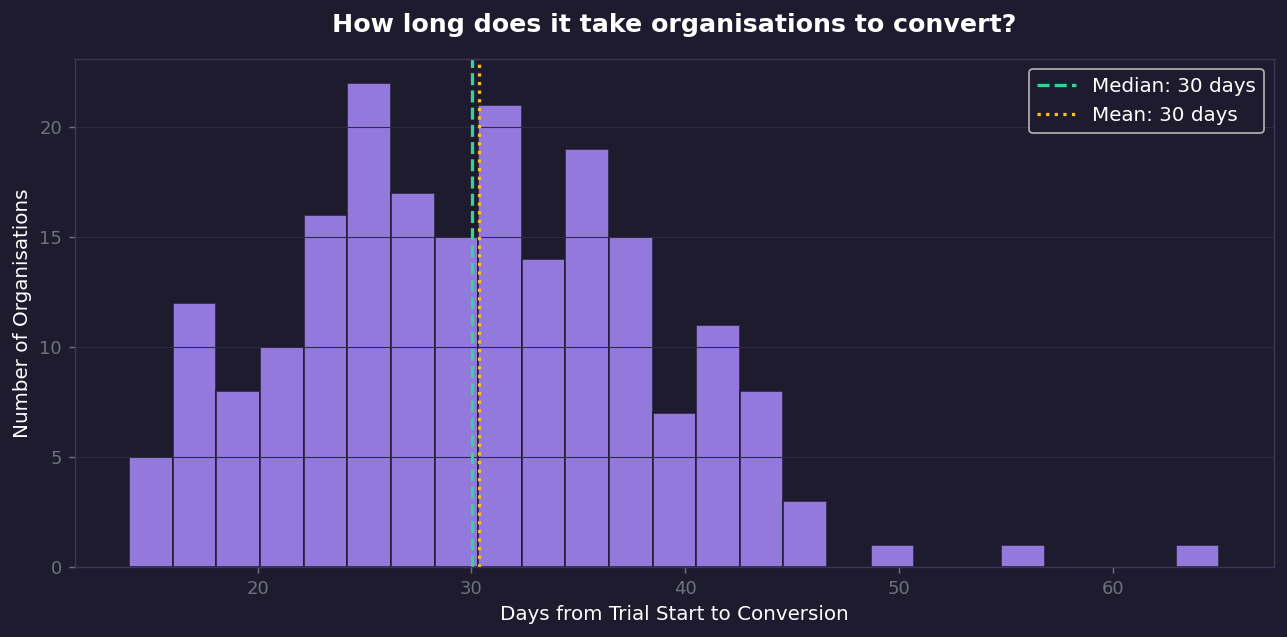

In [34]:
# How long does it take organisations to convert? 

# Get days_to_convert for converted orgs only
ttc = orgs[orgs["converted"] == True]["days_to_convert"].dropna()

median_days = ttc.median()
mean_days   = ttc.mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(DARK)

ax.hist(ttc, bins=25, color=LAVENDER, edgecolor=DARK, alpha=0.85)

# Reference lines
ax.axvline(median_days, color=MINT,  linestyle="--", linewidth=1.8,
           label=f"Median: {median_days:.0f} days")
ax.axvline(mean_days,   color=AMBER, linestyle=":",  linewidth=1.8,
           label=f"Mean: {mean_days:.0f} days")

ax.set_title("How long does it take organisations to convert?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Days from Trial Start to Conversion", fontsize=11)
ax.set_ylabel("Number of Organisations",             fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

### 3. Which activities are most commonly performed during the trial?

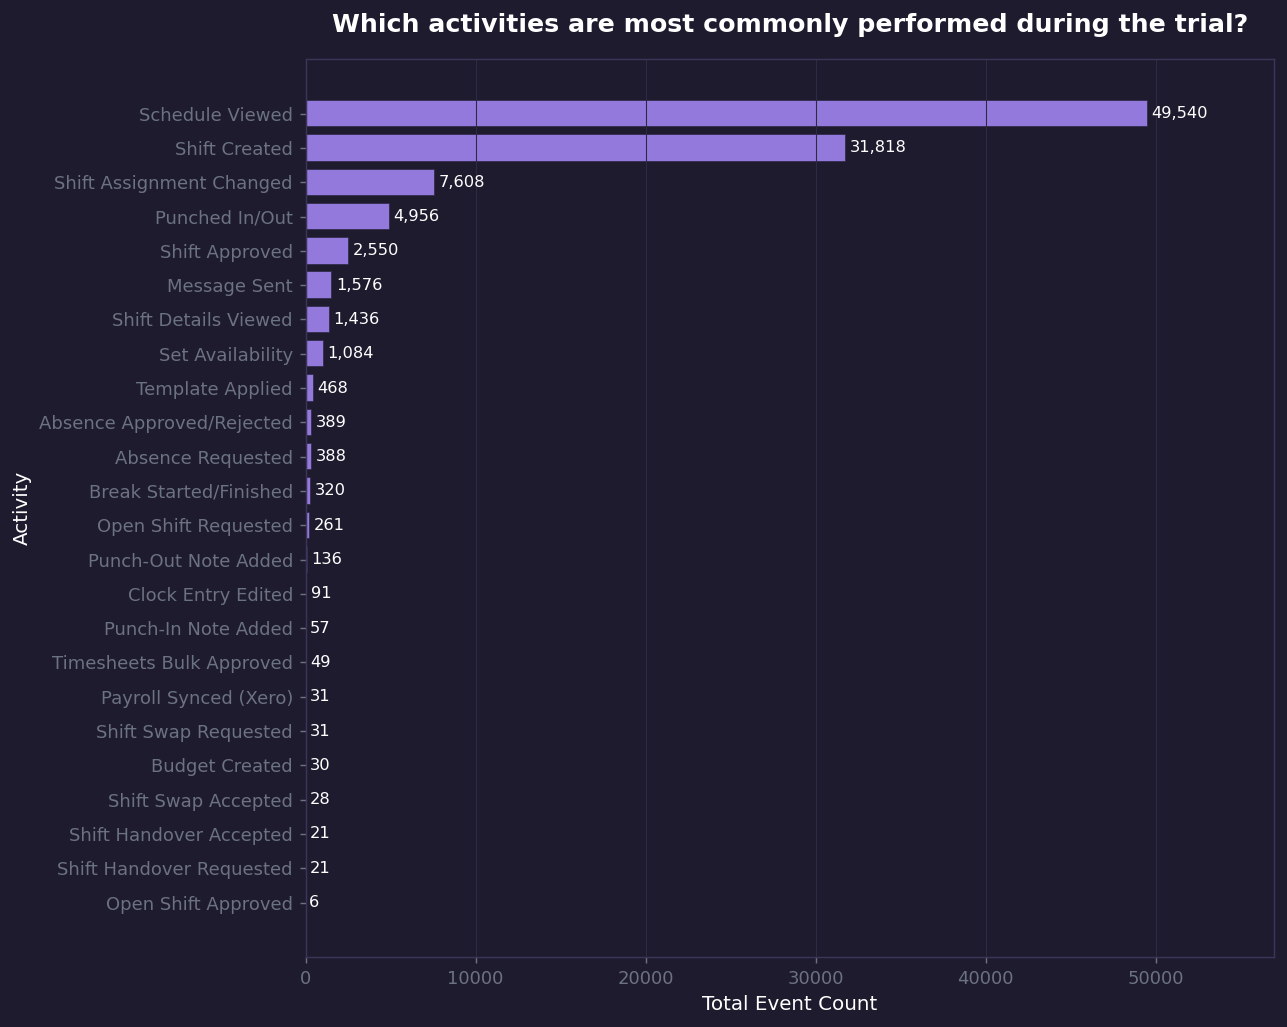

In [35]:
# Which activities are most commonly performed during the trial?

# Count total events per activity across all orgs
activity_counts = (
    df.groupby("activity_canonical")
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=True)
)

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 8), facecolor=DARK)
ax.set_facecolor(DARK)

bars = ax.barh(
    activity_counts["activity_canonical"],
    activity_counts["event_count"],
    color=LAVENDER, edgecolor=DARK, alpha=0.85
)

# Add value labels on each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}", va="center", fontsize=9, color="white")

ax.set_title("Which activities are most commonly performed during the trial?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Total Event Count", fontsize=11)
ax.set_ylabel("Activity",          fontsize=11)
ax.grid(True, axis="x")
ax.set_xlim(0, activity_counts["event_count"].max() * 1.15)

plt.tight_layout()
plt.show()

### How does trial engagement change day by day?

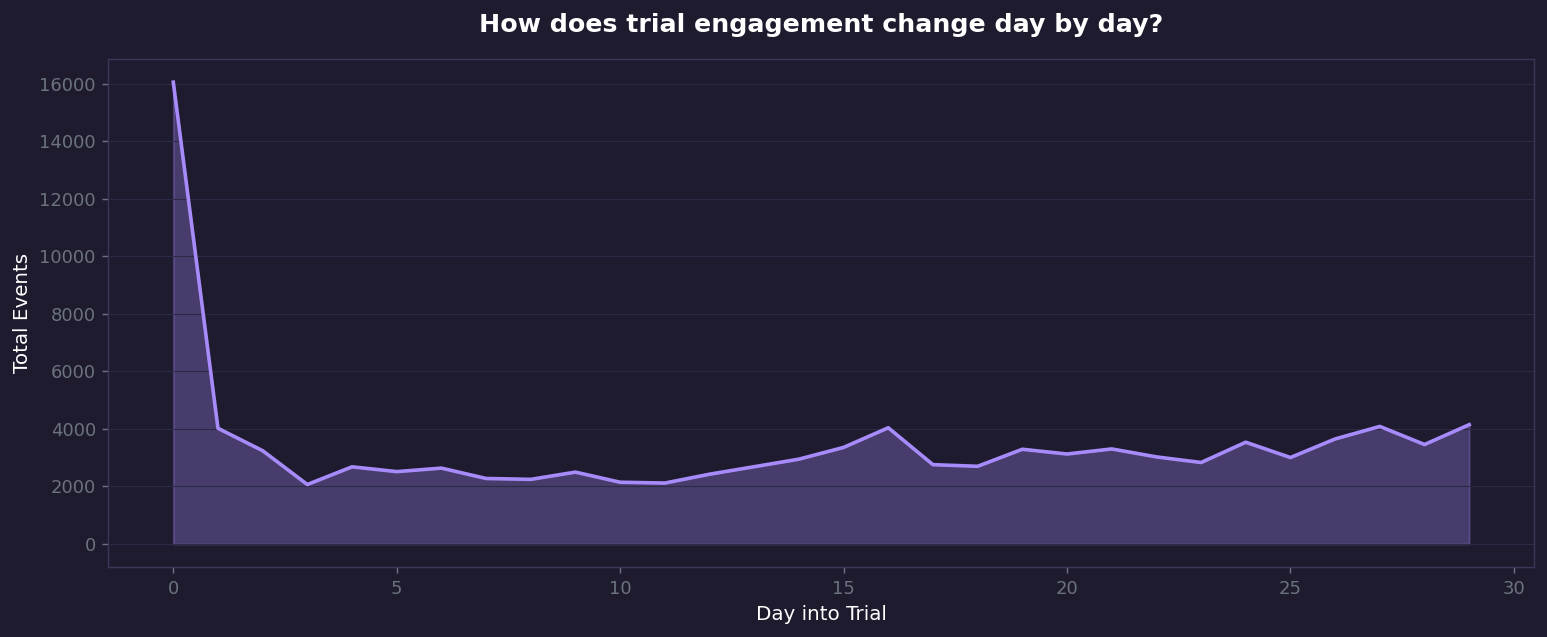

In [36]:
# How does trial engagement change day by day?

# Count events per day into trial
daily_activity = (
    df.groupby("days_from_start")
    .size()
    .reset_index(name="event_count")
)

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK)
ax.set_facecolor(DARK)

ax.fill_between(daily_activity["days_from_start"],
                daily_activity["event_count"],
                alpha=0.3, color=LAVENDER)
ax.plot(daily_activity["days_from_start"],
        daily_activity["event_count"],
        color=LAVENDER, linewidth=2)

ax.set_title("How does trial engagement change day by day?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Day into Trial", fontsize=11)
ax.set_ylabel("Total Events",   fontsize=11)
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

### CONVERSION DRIVER ANALYSIS — CORE TO PROJECT TASK

To understand what separates converting organisations from non-converting ones, three complementary methods are applied:

1. Chi-Square Test — tests whether the usage of each activity is statistically associated with conversion

2. Random Forest — ranks activities by their importance in predicting conversion

3. Logistic Regression — estimates the odds of conversion associated with each activity

Together, these methods provide a statistically grounded view of which in-app behaviours are most indicative of conversion.

In [37]:
# METHOD 1: Statistical Tests (Chi-Square)

print("\n[Method 1] Chi-Square Tests — Activity Usage vs Conversion")

# Define activity columns — all pivoted activity columns in the org-level table
activity_cols = [c for c in orgs.columns if "." in c]

chi_results = []
for act in activity_cols:
    if act not in orgs.columns:
        continue

    # Create a 2x2 Frequency Table (Contingency Table)
    # Rows: Did they use the activity? (True/False)
    # Columns: Did they convert? (True/False)
    contingency = pd.crosstab(orgs[act] > 0, orgs["converted"])
    if contingency.shape == (2, 2):          # needs 2x2 for chi2
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        chi_results.append({"activity": act, "chi2": chi2, "p_value": p})
 
chi_df = pd.DataFrame(chi_results).sort_values("p_value")   # Sort by p_value (lowest p-values = highest statistical significance)
chi_df["significant"] = chi_df["p_value"] < 0.05            # Add a boolean column: True if the p-value is below the standard 0.05 threshold
print(chi_df.to_string(index=False))


[Method 1] Chi-Square Tests — Activity Usage vs Conversion
                              activity     chi2  p_value  significant
         Communication.Message.Created 1.994292 0.157893        False
   Scheduling.OpenShiftRequest.Created 1.608897 0.204647        False
      Timesheets.BulkApprove.Confirmed 1.605099 0.205182        False
               PunchClock.Entry.Edited 0.845312 0.357882        False
              Scheduling.Shift.Created 0.772289 0.379510        False
Scheduling.Template.ApplyModal.Applied 0.747712 0.387202        False
      Scheduling.ShiftHandover.Created 0.730214 0.392814        False
         Scheduling.ShiftSwap.Accepted 0.607385 0.435774        False
          Scheduling.ShiftSwap.Created 0.564050 0.452633        False
       PunchClockEndNote.Add.Completed 0.474377 0.490980        False
                  PunchClock.PunchedIn 0.226641 0.634026        False
     Scheduling.ShiftHandover.Accepted 0.225459 0.634912        False
               Revenue.Budgets

- No activity is statistically significant. All p-values are above **0.05**, meaning we cannot conclude that the usage of any single activity is strongly associated with conversion
  
- Communication.Message.Created has the highest chi-square score (1.99) but still falls short of significance, suggesting it has the weakest association with conversion among all activities

- This is an honest null finding — conversion is likely driven by the volume and breadth of engagement across multiple activities rather than any one specific feature trigger.

In [38]:
# METHOD 2: Random Forest Feature Importance

# Method 2 uses Machine Learning to find which features have the most predictive power, 
#even if they have complex or non-linear relationships with conversion.

print("\n[Method 2] Random Forest Feature Importance")
 
feat_cols = [c for c in activity_cols if c in orgs.columns]
feat_cols += ["total_events", "distinct_activities", "distinct_category", "active_days"]
 
X = orgs[feat_cols].fillna(0)    # Prepare the Features (X): Replace any missing data with 0 (essential for ML models)
y = orgs["converted"].astype(int)  # Prepare the Target (y): Ensure 'converted' is an integer (0 or 1) for the classifier
 
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

rf.fit(X, y)     # Train the model on the full feature set


# Validate the model's reliability using 5-Fold Cross-Validation
# It splits the data 5 ways to ensure the model isn't just "getting lucky" on one slice
# scoring="roc_auc": Measures the model's ability to distinguish between classes (0.5 is random, 1.0 is perfect)
cv_score = cross_val_score(rf, X, y, cv=5, scoring="roc_auc").mean()
print(f"RF CV ROC-AUC: {cv_score:.3f}")
 
importance_df = (
    pd.DataFrame({"feature": feat_cols, "importance": rf.feature_importances_})  # Extract "Feature Importance" — a score showing how much each variable helped the trees make decisions
    .sort_values("importance", ascending=False)
    .head(15)     # show top 15
)
print(importance_df.to_string(index=False))


[Method 2] Random Forest Feature Importance
RF CV ROC-AUC: 0.533
                               feature  importance
                          total_events    0.201253
              Scheduling.Shift.Created    0.181167
                Mobile.Schedule.Loaded    0.124207
                           active_days    0.090849
    Scheduling.Shift.AssignmentChanged    0.082984
                   distinct_activities    0.056327
             Scheduling.Shift.Approved    0.053582
                  PunchClock.PunchedIn    0.043458
         Communication.Message.Created    0.034717
Scheduling.Template.ApplyModal.Applied    0.031627
                     distinct_category    0.020817
           Scheduling.Availability.Set    0.014119
   Scheduling.OpenShiftRequest.Created    0.011448
              Absence.Request.Approved    0.008853
               Absence.Request.Created    0.008708


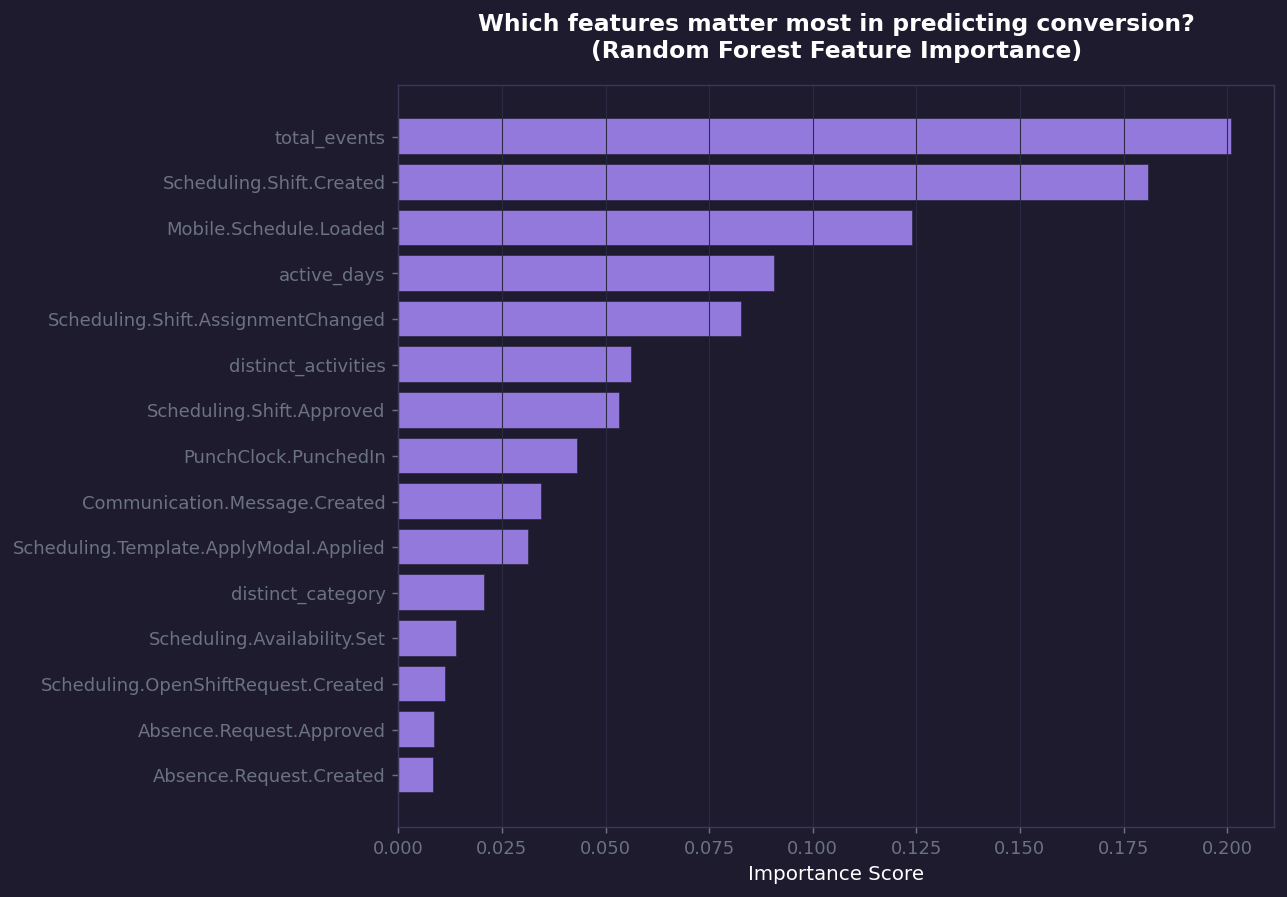

In [39]:
# ── Visualize: Which features matter most in predicting conversion? ───────────
imp = importance_df.sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7), facecolor=DARK)
ax.set_facecolor(DARK)

ax.barh(imp["feature"], imp["importance"], color=LAVENDER, edgecolor=DARK, alpha=0.85)

ax.set_title("Which features matter most in predicting conversion?\n(Random Forest Feature Importance)",
             fontsize=13, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Importance Score", fontsize=11)
ax.grid(True, axis="x")

plt.tight_layout()
plt.show()

- Overall engagement volume matters most — total_events and active_days are the top predictors, confirming that how much an organisation engages matters more than which specific feature they use

- Scheduling is the dominant activity — three of the top ten features are scheduling activities (Shift.Created, AssignmentChanged, Shift.Approved), making it the clearest behavioural signal during the trial

- The model's ROC-AUC of 0.533 is barely above chance (0.5), indicating that individual activity usage alone is a weak predictor of conversion, consistent with the chi-square null findings.


In [40]:
# METHOD 3: Logistic Regression Odds Ratios
print("\n[Method 3] Logistic Regression — Odds Ratios")
 
# Use binary flags for activities to get interpretable ORs
lr_feats  = [c for c in activity_cols if c in orgs.columns]    # Selecting all activity columns available in the dataframe
X_bin     = (orgs[lr_feats].fillna(0) > 0).astype(int)
scaler    = StandardScaler()    # Feature Scaling (Standardization)
X_scaled  = scaler.fit_transform(X_bin)
 
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)   # Initialize Logistic Regression
lr.fit(X_scaled, y)
 
lr_cv = cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc").mean()   # Validate model performance using Cross-Validation
print(f"LR CV ROC-AUC: {lr_cv:.3f}")
 
or_df = pd.DataFrame({
    "feature":  lr_feats,
    "coef":     lr.coef_[0],
    "odds_ratio": np.exp(lr.coef_[0])   # Calculate Odds Ratios (OR), easy to read
}).sort_values("odds_ratio", ascending=False)

print(or_df.to_string(index=False))    # Print the table ranked from most positive impact to most negative


[Method 3] Logistic Regression — Odds Ratios
LR CV ROC-AUC: 0.513
                               feature      coef  odds_ratio
      Scheduling.ShiftHandover.Created  0.311778    1.365851
              Absence.Request.Rejected  0.147424    1.158845
   Scheduling.OpenShiftRequest.Created  0.096982    1.101841
              Scheduling.Shift.Created  0.092621    1.097046
              ShiftDetails.View.Opened  0.088802    1.092864
 Integration.Xero.PayrollExport.Synced  0.081398    1.084802
Scheduling.Template.ApplyModal.Applied  0.056589    1.058220
     PunchClockStartNote.Add.Completed  0.054191    1.055686
                 PunchClock.PunchedOut  0.053588    1.055050
                  PunchClock.PunchedIn  0.053407    1.054859
           Scheduling.Availability.Set  0.034677    1.035285
             Scheduling.Shift.Approved  0.029307    1.029741
               Absence.Request.Created  0.027023    1.027391
                Mobile.Schedule.Loaded  0.013303    1.013392
               Bre

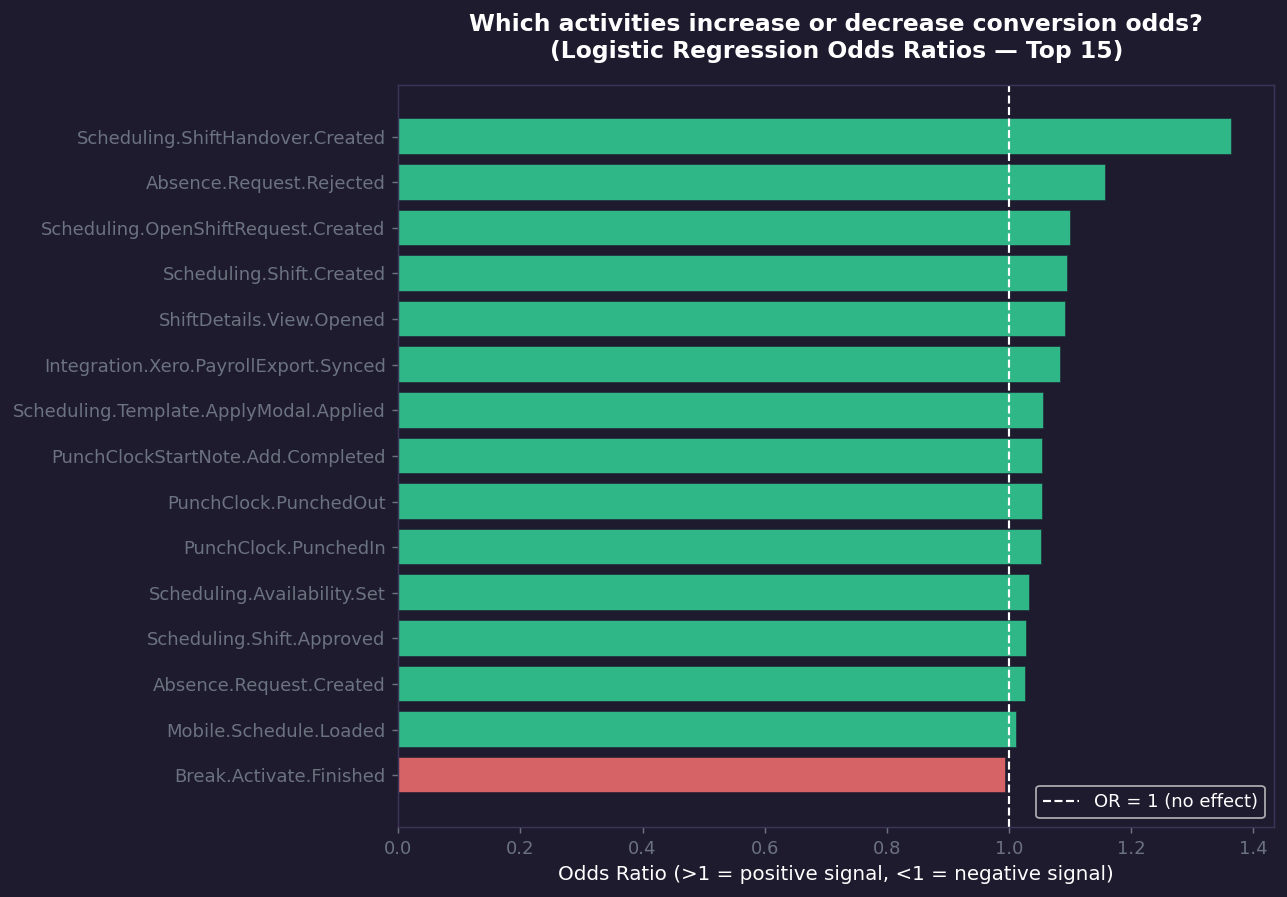

In [41]:
# Visualize: Which activities increase or decrease conversion odds? 
or_top = or_df.head(15).sort_values("odds_ratio")

# Color bars green if OR > 1 (positive signal), red if OR < 1 (negative signal)
colors = [MINT if v > 1 else CORAL for v in or_top["odds_ratio"]]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=DARK)
ax.set_facecolor(DARK)

ax.barh(or_top["feature"], or_top["odds_ratio"],
        color=colors, edgecolor=DARK, alpha=0.85)

# Reference line at OR = 1 (no effect)
ax.axvline(1, color="white", linestyle="--", linewidth=1.2,
           label="OR = 1 (no effect)")

ax.set_title("Which activities increase or decrease conversion odds?\n(Logistic Regression Odds Ratios — Top 15)",
             fontsize=13, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Odds Ratio (>1 = positive signal, <1 = negative signal)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(False, axis="x")

plt.tight_layout()
plt.show()

- Scheduling.ShiftHandover.Created has the highest odds ratio (1.37), meaning organisations that requested shift handovers were 37% more likely to convert, suggesting deeper scheduling workflow adoption is a positive conversion signal

- All odds ratios are close to 1.0, indicating that no single activity dramatically increases or decreases the probability of conversion, reinforcing the weak individual-feature findings from the previous two methods

- Timesheets.BulkApprove.Confirmed has the lowest odds ratio (0.59), which is counterintuitive, organisations that bulk-approved timesheets were actually less likely to convert, possibly because they completed the trial workflow without feeling the need to pay for continued access.

### ENGAGEMENT SEGMENTATION

In [42]:
#  How does conversion rate vary by level of trial engagement? 

# Segment orgs by distinct activities using manual bins
bins   = [0, 1, 3, 7, 100]
labels = ["Low (1)", "Medium (2-3)", "High (4-7)", "Power (8+)"]

orgs["engagement_segment"] = pd.cut(
    orgs["distinct_activities"],
    bins=bins,
    labels=labels
)

# Summary per segment
seg_summary = (
    orgs.groupby("engagement_segment", observed=True)
    .agg(
        n_orgs          = ("organization_id", "count"),
        conversion_rate = ("converted", "mean"),
        avg_events      = ("total_events", "mean"),
        avg_active_days = ("active_days", "mean")
    )
    .reset_index()
)

print(seg_summary)

  engagement_segment  n_orgs  conversion_rate  avg_events  avg_active_days
0            Low (1)     395         0.205063    5.964557         1.118987
1       Medium (2-3)     336         0.226190   25.360119         1.898810
2         High (4-7)     168         0.190476  228.732143         9.922619
3         Power (8+)      67         0.253731  799.865672        19.522388


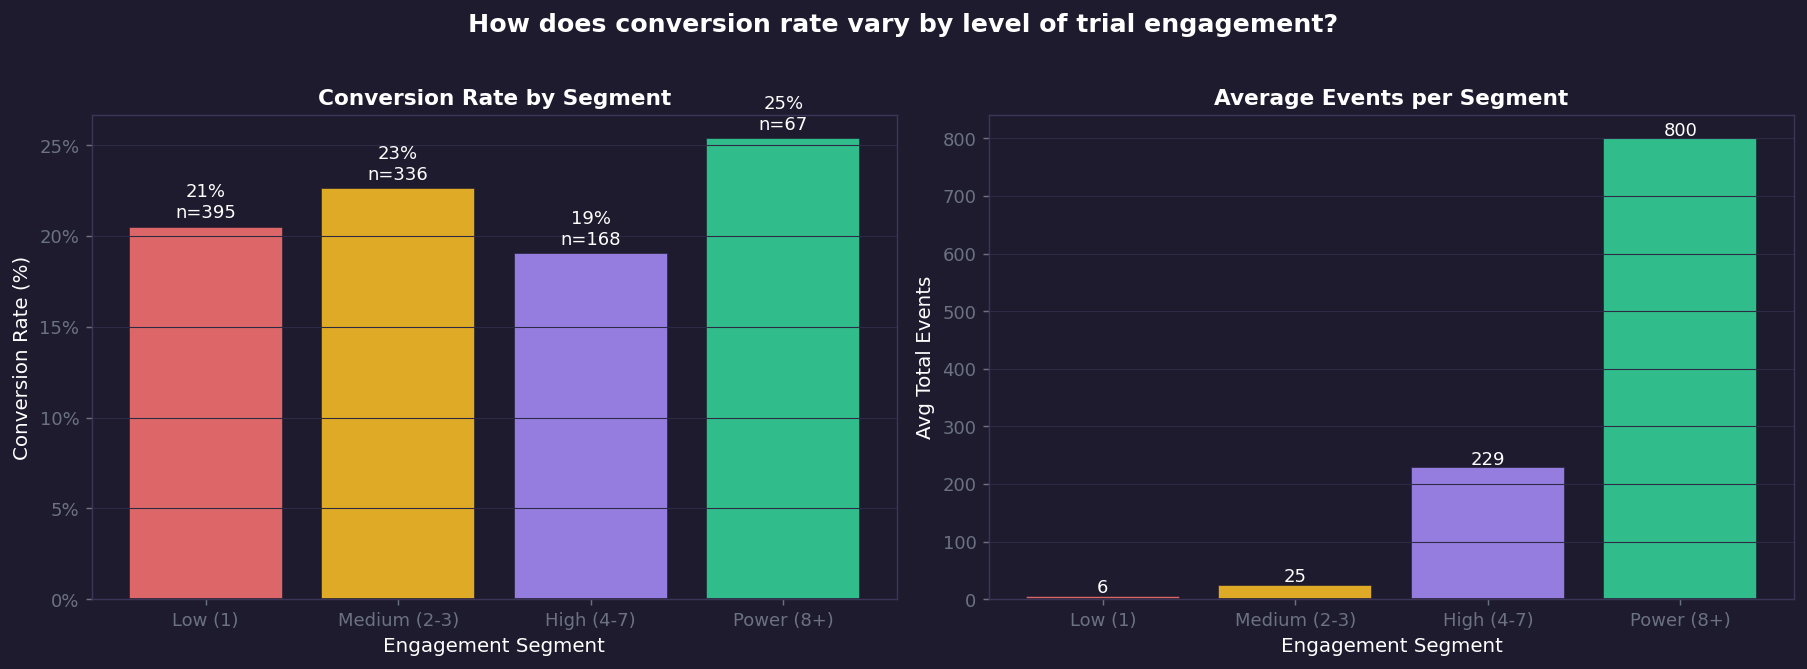

In [43]:
#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle("How does conversion rate vary by level of trial engagement?",
             fontsize=14, fontweight="bold", color="white", y=1.02)

seg_colors = [CORAL, AMBER, LAVENDER, MINT]

# Panel 1: Conversion rate per segment 
axes[0].set_facecolor(DARK)
bars = axes[0].bar(
    seg_summary["engagement_segment"],
    seg_summary["conversion_rate"] * 100,
    color=seg_colors, edgecolor=DARK, alpha=0.88
)
axes[0].set_title("Conversion Rate by Segment", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Engagement Segment", fontsize=11)
axes[0].set_ylabel("Conversion Rate (%)",  fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].grid(True, axis="y")

for bar, (_, row) in zip(bars, seg_summary.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['conversion_rate']:.0%}\nn={row['n_orgs']}",
        ha="center", fontsize=10, color="white"
    )

#  Panel 2: Average events per segment 
axes[1].set_facecolor(DARK)
bars2 = axes[1].bar(
    seg_summary["engagement_segment"],
    seg_summary["avg_events"],
    color=seg_colors, edgecolor=DARK, alpha=0.88
)
axes[1].set_title("Average Events per Segment", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Engagement Segment", fontsize=11)
axes[1].set_ylabel("Avg Total Events",   fontsize=11)
axes[1].grid(True, axis="y")

for bar, (_, row) in zip(bars2, seg_summary.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{row['avg_events']:.0f}",
        ha="center", fontsize=10, color="white"
    )

plt.tight_layout()
plt.show()

- Conversion generally increases with deeper engagement, with Power users (8+ activities) showing the highest conversion rate (~25%), suggesting strong product interaction drives value realization.

- Moderate engagement performs inconsistently, as High (4–7) users convert less (~19%) than Medium (2–3) users (~23%), indicating that not all activity types contribute equally to conversion.

- Low engagement still converts (~20%), implying that some organisations may convert with minimal usage, but scaling conversion likely depends on driving meaningful, not just frequent, engagement.

### DEFINE TRIAL GOALS  (data-driven, product-value grounded)

Here, we are defining specific "Success Milestones" (Trial Goals) to see if reaching them predicts a customer actually paying for the product.

"""
APPROACH:
We combine three signals to select goals:
  1. Statistically significant chi-square (p<0.05)
  2. High odds ratio from logistic regression (OR > 1.5)
  3. Product-value logic: activities that represent completing a workflow
     end-to-end (scheduling → shift live → punch-in/out → timesheet approval)
 
The goals are intentionally achievable (completion rate 25-70%) so they
discriminate between engaged and non-engaged orgs. 

We will define 5 goals covering the platform's core value pillars.
"""

In [44]:
# =============================================================================
# DEFINE TRIAL GOALS (data-driven, product-value grounded)
# =============================================================================

# Core Goal: Creating at least 3 shifts (indicates they are actually using the scheduler)
# Visibility Goal: Did they check the schedule on mobile at least once?
# Feature Adoption: Did they try the PunchClock (In OR Out)?
# Admin Efficiency: Did they approve a shift or bulk-approve timesheets?
# Engagement: Did they send at least one team message?

TRIAL_GOALS = {
    "goal_scheduling_core":    {"activities": ["Scheduling.Shift.Created"],                                        "threshold": 3},
    "goal_schedule_viewed":    {"activities": ["Mobile.Schedule.Loaded"],                                          "threshold": 1},
    "goal_punchclock_used":    {"activities": ["PunchClock.PunchedIn", "PunchClock.PunchedOut"],                   "threshold": 1, "combine": "any"},
    "goal_timesheet_approved": {"activities": ["Scheduling.Shift.Approved", "Timesheets.BulkApprove.Confirmed"],   "threshold": 1, "combine": "any"},
    "goal_team_comms":         {"activities": ["Communication.Message.Created"],                                   "threshold": 1},
}

# Compute goal completion per org
goal_results = orgs[["organization_id", "converted"]].copy()

for goal, cfg in TRIAL_GOALS.items():
    acts = [a for a in cfg["activities"] if a in orgs.columns]   # Filter for activity columns that actually exist in the 'orgs' DataFrame
    if not acts:
        goal_results[goal] = False                         # If none of the required activities exist in the data, mark the goal as failed (False)
        continue
    if cfg.get("combine") == "any":
        # Org passes if ANY of the activities was used at least once
        goal_results[goal] = (orgs[acts] > 0).any(axis=1)
    else:
        # Sum of all listed activities must meet threshold
        goal_results[goal] = orgs[acts].sum(axis=1) >= cfg["threshold"]  

goal_cols = list(TRIAL_GOALS.keys())   # Storing the list of goal names for easy reference in future plotting or tables

In [45]:
# Print completion rates overall and by conversion status
print("Goal completion rates:\n")
for g in goal_cols:
    overall = goal_results[g].mean()
    c_rate  = goal_results[goal_results["converted"] == True][g].mean()
    n_rate  = goal_results[goal_results["converted"] == False][g].mean()
    print(f"  {g:<35} overall={overall:.0%}  converters={c_rate:.0%}  non={n_rate:.0%}")

# Save goal results
goal_results.to_csv(f"{OUTPUT_PATH}/trial_goals.csv", index=False)
print("\nSaved → outputs/trial_goals.csv")

Goal completion rates:

  goal_scheduling_core                overall=58%  converters=58%  non=58%
  goal_schedule_viewed                overall=47%  converters=47%  non=47%
  goal_punchclock_used                overall=22%  converters=23%  non=21%
  goal_timesheet_approved             overall=21%  converters=21%  non=21%
  goal_team_comms                     overall=15%  converters=12%  non=16%

Saved → outputs/trial_goals.csv


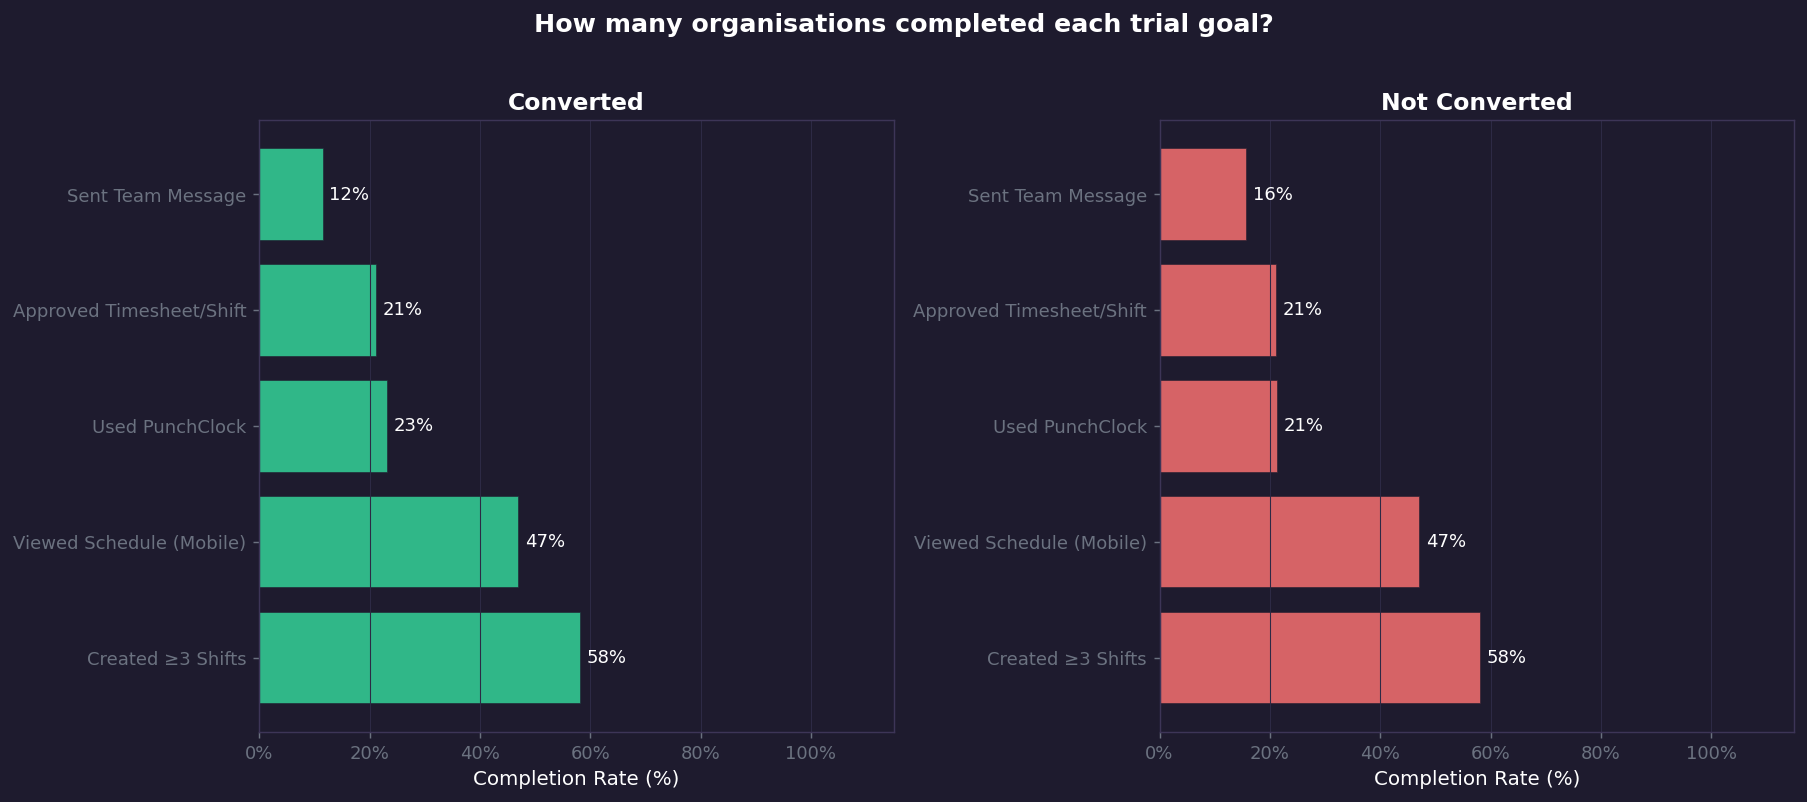

In [46]:
#  Visualize: How many organisations completed each trial goal? 

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK)
fig.suptitle("How many organisations completed each trial goal?",
             fontsize=14, fontweight="bold", color="white", y=1.02)

goal_labels = {
    "goal_scheduling_core":    "Created ≥3 Shifts",
    "goal_schedule_viewed":    "Viewed Schedule (Mobile)",
    "goal_punchclock_used":    "Used PunchClock",
    "goal_timesheet_approved": "Approved Timesheet/Shift",
    "goal_team_comms":         "Sent Team Message",
}

for i, (label, subset) in enumerate([
    ("Converted",     goal_results[goal_results["converted"] == True]),
    ("Not Converted", goal_results[goal_results["converted"] == False]),
]):
    rates  = subset[goal_cols].mean()
    labels = [goal_labels[g] for g in goal_cols]
    color  = MINT if i == 0 else CORAL

    axes[i].set_facecolor(DARK)
    bars = axes[i].barh(labels, rates.values * 100, color=color, edgecolor=DARK, alpha=0.85)
    axes[i].set_title(label, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Completion Rate (%)", fontsize=11)
    axes[i].set_xlim(0, 115)
    axes[i].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    axes[i].grid(True, axis="x")

    for bar, v in zip(bars, rates.values):
        axes[i].text(v * 100 + 1, bar.get_y() + bar.get_height() / 2,
                     f"{v:.0%}", va="center", fontsize=10, color="white")

plt.tight_layout()
plt.show()

- Scheduling Core and Schedule Viewed are the most completed goals — **58%** and **47%** of all organisations respectively, confirming that shift creation and mobile schedule viewing are the most natural entry points into the platform.
  
- Completion rates are nearly identical between converters and non-converters across all five goals, reinforcing the earlier finding that no single activity or goal is a strong standalone predictor of conversion

- Team Communication is the least completed goal **(15%)** and is actually slightly higher among non-converters **(16%)** than converters **(12%)**, suggesting that sending messages during the trial does not drive conversion and may not belong in the activation definition without further validation

### TRIAL ACTIVATION — Organizations that completed ALL 5 goals

In [47]:

# TRIAL ACTIVATION — Organizations that completed ALL 5 goals


goal_results["is_activated"]    = goal_results[goal_cols].all(axis=1)
goal_results["goals_completed"] = goal_results[goal_cols].sum(axis=1)  # Create a numeric count: How many total goals (out of 5) did this org complete?

# Activation tier, a function to bucket organizations into 'Engagement Tiers'
def assign_tier(row):
    if row["is_activated"]:         return "Fully Activated"   # Tier 1: The Gold Standard (100% completion)
    if row["goals_completed"] >= 3: return "Partially (≥3 goals)"  # Tier 2: Heavy users who haven't quite finished everything
    if row["goals_completed"] >= 1: return "Early (1-2 goals)"     # Tier 3: Casual users just testing the waters
    return "No Activation"                                         # Tier 4: Registered but did essentially nothing


goal_results["activation_tier"] = goal_results.apply(assign_tier, axis=1)

# Summary
tier_order   = ["No Activation", "Early (1-2 goals)", "Partially (≥3 goals)", "Fully Activated"]
tier_summary = (
    goal_results.groupby("activation_tier")
    .agg(
        n_orgs          = ("organization_id", "count"),  # Count how many orgs fall in this bucket
        conversion_rate = ("converted", "mean")          # Calculate the actual conversion % for this bucket
    )
    .reindex(tier_order)
    .reset_index()
)

print(tier_summary)

        activation_tier  n_orgs  conversion_rate
0         No Activation     196         0.250000
1     Early (1-2 goals)     544         0.191176
2  Partially (≥3 goals)     158         0.265823
3       Fully Activated      68         0.161765


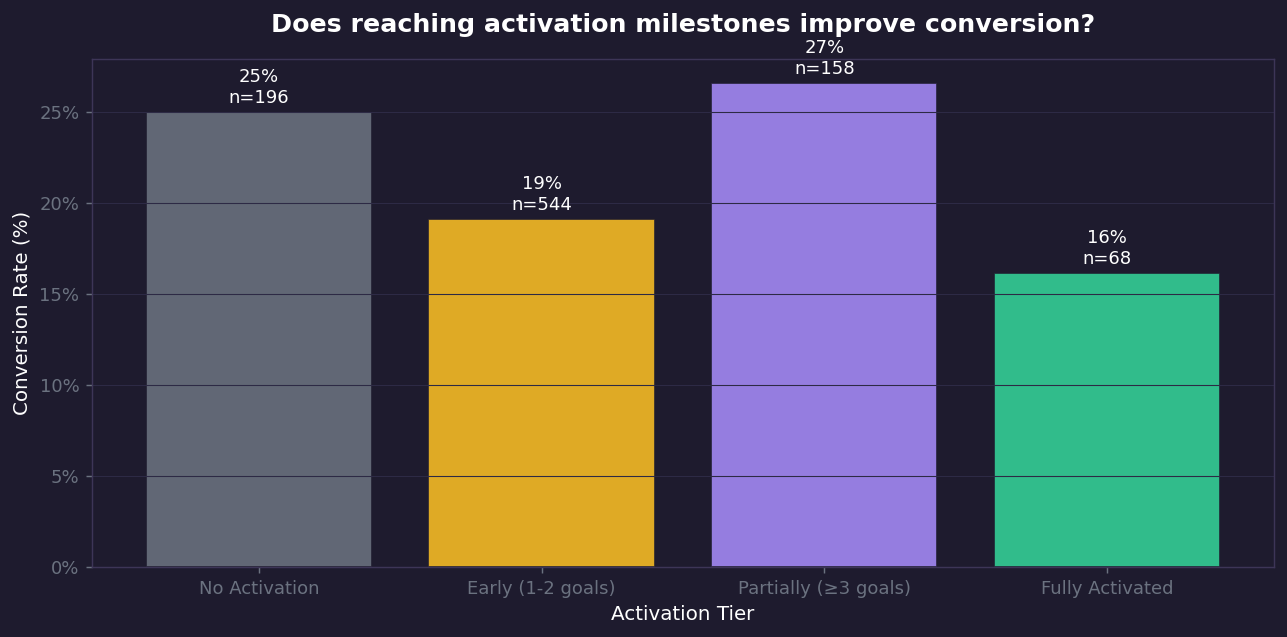

In [48]:
# ── Visualize: Does reaching activation milestones improve conversion? ────────

fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(DARK)

tier_colors = [GRAY, AMBER, LAVENDER, MINT]
bars = ax.bar(
    tier_summary["activation_tier"],
    tier_summary["conversion_rate"] * 100,
    color=tier_colors, edgecolor=DARK, alpha=0.88
)

ax.set_title("Does reaching activation milestones improve conversion?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Activation Tier",    fontsize=11)
ax.set_ylabel("Conversion Rate (%)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.tick_params(axis="x", labelsize=10)
ax.grid(True, axis="y")

for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['conversion_rate']:.0%}\nn={row['n_orgs']}",
        ha="center", fontsize=10, color="white"
    )

plt.tight_layout()
plt.show()

- Fully Activated organisations have the lowest conversion rate (16%). Surprisingly, completing all 5 goals does not lead to the highest conversion, suggesting the current activation definition may not be well-calibrated to predict conversion

- Partially activated organisations (≥3 goals) have the highest conversion rate (27%) — indicating that a 3-goal threshold may be a more meaningful activation benchmark than requiring all 5 goals

- Even organisations with no activation convert at 25% — this challenges the entire activation framework and suggests that conversion at Splendor Analytics may be driven by factors outside of in-app behaviour, such as sales outreach, pricing, or organisational decision-making timelines.

## TASK 2

### Building an SQL-based model providing two sources that would live in the marts layer of the data warehouse:



connecting Python directly to MySQL

In [49]:
import pandas as pd
import mysql.connector


### Connect Python to MySQL and insert the data

In [50]:
import mysql.connector
import pandas as pd
import numpy as np


In [58]:
# Task 2 SQL models were built via Python-to-MySQL connection.
# To reproduce, update credentials below to match your local MySQL setup.
try:
    conn = mysql.connector.connect(
        host     = "localhost",
        user     = "root",
        password = "1234",   # ← update with your credentials
        database = "splendor_analytics"
    )
    print("✓ Connected to MySQL")
except Exception as e:
    print(f"MySQL connection skipped: {e}")
    print("Note: Update credentials above to reproduce SQL models locally.")

✓ Connected to MySQL


In [52]:
import pandas as pd
import numpy as np

# Load cleaned data
df2 = pd.read_csv(f"{OUTPUT_PATH}/clean_events.csv")

# Replace NaN with None so MySQL stores as NULL
df2 = df2.where(pd.notnull(df2), None)

print(f"Total rows to insert: {len(df2)}")
print(df2.dtypes)
print(df2.head(3))

Total rows to insert: 102895
organization_id         str
activity_name           str
timestamp               str
converted              bool
converted_at            str
trial_start             str
trial_end               str
days_from_start       int64
trial_length          int64
before_conversion      bool
activity_canonical      str
activity_category       str
dtype: object
                    organization_id             activity_name  \
0  0040dd9ab132b92d5d04bc3acf14d2e2  Scheduling.Shift.Created   
1  0040dd9ab132b92d5d04bc3acf14d2e2  Scheduling.Shift.Created   
2  0040dd9ab132b92d5d04bc3acf14d2e2  Scheduling.Shift.Created   

             timestamp  converted converted_at          trial_start  \
0  2024-03-27 11:03:53      False          NaN  2024-03-27 10:11:39   
1  2024-03-27 11:04:52      False          NaN  2024-03-27 10:11:39   
2  2024-03-27 11:04:53      False          NaN  2024-03-27 10:11:39   

             trial_end  days_from_start  trial_length  before_conversion  \

In [53]:
# Fix converted_at — replace NaN with None for MySQL NULL
df2["converted_at"] = df2["converted_at"].replace({np.nan: None})

# Confirm fix
print(f"converted_at NaN count  : {df2['converted_at'].isna().sum()}")
print(f"converted_at None count : {(df2['converted_at'].isnull()).sum()}")
print(df2[["converted", "converted_at", "before_conversion"]].head(3))

converted_at NaN count  : 80672
converted_at None count : 80672
   converted converted_at  before_conversion
0      False         None              False
1      False         None              False
2      False         None              False


In [54]:
insert_query = """
    INSERT INTO stg_trial_events (
        organization_id, activity_name, timestamp, converted,
        converted_at, trial_start, trial_end, days_from_start,
        trial_length, before_conversion, activity_canonical, activity_category
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

rows       = list(df2.itertuples(index=False, name=None))
batch_size = 5000
total      = len(rows)

for i in range(0, total, batch_size):
    batch = rows[i : i + batch_size]
    cursor.executemany(insert_query, batch)
    conn.commit()
    print(f"  Inserted rows {i+1} to {min(i+batch_size, total)} of {total}")

print(f"\n✓ All {total} rows inserted")

  Inserted rows 1 to 5000 of 102895
  Inserted rows 5001 to 10000 of 102895
  Inserted rows 10001 to 15000 of 102895
  Inserted rows 15001 to 20000 of 102895
  Inserted rows 20001 to 25000 of 102895
  Inserted rows 25001 to 30000 of 102895
  Inserted rows 30001 to 35000 of 102895
  Inserted rows 35001 to 40000 of 102895
  Inserted rows 40001 to 45000 of 102895
  Inserted rows 45001 to 50000 of 102895
  Inserted rows 50001 to 55000 of 102895
  Inserted rows 55001 to 60000 of 102895
  Inserted rows 60001 to 65000 of 102895
  Inserted rows 65001 to 70000 of 102895
  Inserted rows 70001 to 75000 of 102895
  Inserted rows 75001 to 80000 of 102895
  Inserted rows 80001 to 85000 of 102895
  Inserted rows 85001 to 90000 of 102895
  Inserted rows 90001 to 95000 of 102895
  Inserted rows 95001 to 100000 of 102895
  Inserted rows 100001 to 102895 of 102895

✓ All 102895 rows inserted


In [55]:
cursor.execute("SELECT COUNT(*) FROM stg_trial_events")
print(f"✓ Total rows in MySQL: {cursor.fetchone()[0]}")

✓ Total rows in MySQL: 308685


###  Create intermediate view

In [56]:
cursor.execute("DROP VIEW IF EXISTS int_org_activity_summary")

cursor.execute("""
    CREATE VIEW int_org_activity_summary AS
    SELECT
        organization_id,
        MAX(converted)                             AS converted,
        MAX(converted_at)                          AS converted_at,
        MAX(trial_start)                           AS trial_start,
        MAX(trial_end)                             AS trial_end,
        COUNT(*)                                   AS total_events,
        COUNT(DISTINCT activity_name)              AS distinct_activities,
        COUNT(DISTINCT activity_category)          AS distinct_categories,
        COUNT(DISTINCT DATE(timestamp))            AS active_days,
        SUM(activity_name = 'Scheduling.Shift.Created')                AS cnt_shift_created,
        SUM(activity_name = 'Scheduling.Shift.Approved')               AS cnt_shift_approved,
        SUM(activity_name = 'Mobile.Schedule.Loaded')                  AS cnt_schedule_loaded,
        SUM(activity_name = 'PunchClock.PunchedIn')                    AS cnt_punched_in,
        SUM(activity_name = 'PunchClock.PunchedOut')                   AS cnt_punched_out,
        SUM(activity_name = 'Timesheets.BulkApprove.Confirmed')        AS cnt_timesheet_bulk_approved,
        SUM(activity_name = 'Communication.Message.Created')           AS cnt_message_created,
        SUM(activity_name = 'Scheduling.Shift.AssignmentChanged')      AS cnt_shift_assignment_changed,
        SUM(activity_name = 'Scheduling.Template.ApplyModal.Applied')  AS cnt_template_applied,
        SUM(activity_name = 'Scheduling.Availability.Set')             AS cnt_availability_set,
        SUM(activity_name = 'Scheduling.ShiftSwap.Created')            AS cnt_shift_swap_created,
        SUM(activity_name = 'Scheduling.ShiftSwap.Accepted')           AS cnt_shift_swap_accepted,
        SUM(activity_name = 'Scheduling.ShiftHandover.Created')        AS cnt_shift_handover_created,
        SUM(activity_name = 'Scheduling.ShiftHandover.Accepted')       AS cnt_shift_handover_accepted,
        SUM(activity_name = 'Scheduling.OpenShiftRequest.Created')     AS cnt_open_shift_req_created,
        SUM(activity_name = 'Scheduling.OpenShiftRequest.Approved')    AS cnt_open_shift_req_approved,
        SUM(activity_name IN (
            'Shift.View.Opened','ShiftDetails.View.Opened'))           AS cnt_shift_viewed,
        SUM(activity_name = 'Absence.Request.Created')                 AS cnt_absence_created,
        SUM(activity_name = 'Absence.Request.Approved')                AS cnt_absence_approved,
        SUM(activity_name = 'Absence.Request.Rejected')                AS cnt_absence_rejected,
        SUM(activity_name = 'PunchClock.Entry.Edited')                 AS cnt_entry_edited,
        SUM(activity_name = 'PunchClockStartNote.Add.Completed')       AS cnt_start_note,
        SUM(activity_name = 'PunchClockEndNote.Add.Completed')         AS cnt_end_note,
        SUM(activity_name IN (
            'Break.Activate.Started','Break.Activate.Finished'))       AS cnt_break_events,
        SUM(activity_name = 'Integration.Xero.PayrollExport.Synced')   AS cnt_payroll_synced,
        SUM(activity_name = 'Revenue.Budgets.Created')                 AS cnt_budget_created
    FROM stg_trial_events
    GROUP BY organization_id
""")
conn.commit()

# Verify
cursor.execute("SELECT COUNT(*) FROM int_org_activity_summary")
print(f"✓ int_org_activity_summary rows: {cursor.fetchone()[0]}")

✓ int_org_activity_summary rows: 966


In [59]:
# Drop in correct order — child table first, then parent
cursor.execute("DROP TABLE IF EXISTS mart_trial_activation")  # child first
cursor.execute("DROP TABLE IF EXISTS mart_trial_goals")       # parent second
conn.commit()
print("✓ Tables dropped successfully")

✓ Tables dropped successfully


### Create mart_trial_goals

In [60]:
# Recreate Parent Table: mart_trial_goals
cursor.execute("""
    CREATE TABLE mart_trial_goals AS
    SELECT
        organization_id,
        converted,
        trial_start,
        trial_end,
        CASE WHEN cnt_shift_created >= 3
             THEN 1 ELSE 0 END                  AS goal_scheduling_core,
        CASE WHEN cnt_schedule_loaded >= 1
             THEN 1 ELSE 0 END                  AS goal_schedule_viewed,
        CASE WHEN (cnt_punched_in +
                   cnt_punched_out) >= 1
             THEN 1 ELSE 0 END                  AS goal_punchclock_used,
        CASE WHEN (cnt_shift_approved +
                   cnt_timesheet_bulk_approved) >= 1
             THEN 1 ELSE 0 END                  AS goal_timesheet_approved,
        CASE WHEN cnt_message_created >= 1
             THEN 1 ELSE 0 END                  AS goal_team_comms,
        cnt_shift_created,
        cnt_schedule_loaded,
        cnt_punched_in,
        cnt_punched_out,
        cnt_shift_approved,
        cnt_timesheet_bulk_approved,
        cnt_message_created,
        total_events,
        distinct_activities,
        active_days
    FROM int_org_activity_summary
""")
conn.commit()

cursor.execute("SELECT COUNT(*) FROM mart_trial_goals")
print(f"✓ mart_trial_goals created — {cursor.fetchone()[0]} rows")


✓ mart_trial_goals created — 966 rows


### Create mart_trial_activation

In [61]:
# Recreate Child Table: mart_trial_activation

cursor.execute("""
    CREATE TABLE mart_trial_activation AS
    SELECT
        organization_id,
        converted,
        trial_start,
        trial_end,
        goal_scheduling_core,
        goal_schedule_viewed,
        goal_punchclock_used,
        goal_timesheet_approved,
        goal_team_comms,
        (goal_scheduling_core    +
         goal_schedule_viewed    +
         goal_punchclock_used    +
         goal_timesheet_approved +
         goal_team_comms)                        AS goals_completed,
        CASE WHEN (goal_scheduling_core    +
                   goal_schedule_viewed    +
                   goal_punchclock_used    +
                   goal_timesheet_approved +
                   goal_team_comms) = 5
             THEN 1 ELSE 0 END                   AS is_activated,
        CASE
            WHEN (goal_scheduling_core    +
                  goal_schedule_viewed    +
                  goal_punchclock_used    +
                  goal_timesheet_approved +
                  goal_team_comms) = 5    THEN 'Fully Activated'
            WHEN (goal_scheduling_core    +
                  goal_schedule_viewed    +
                  goal_punchclock_used    +
                  goal_timesheet_approved +
                  goal_team_comms) >= 3   THEN 'Partially Activated (>=3 goals)'
            WHEN (goal_scheduling_core    +
                  goal_schedule_viewed    +
                  goal_punchclock_used    +
                  goal_timesheet_approved +
                  goal_team_comms) >= 1   THEN 'Early Exploration (1-2 goals)'
            ELSE                               'No Activation'
        END                                      AS activation_tier,
        CASE WHEN converted = 1
              AND (goal_scheduling_core    +
                   goal_schedule_viewed    +
                   goal_punchclock_used    +
                   goal_timesheet_approved +
                   goal_team_comms) = 0
             THEN 1 ELSE 0 END                   AS converted_without_activation,
        CASE WHEN (goal_scheduling_core    +
                   goal_schedule_viewed    +
                   goal_punchclock_used    +
                   goal_timesheet_approved +
                   goal_team_comms) = 5
              AND converted = 0
             THEN 1 ELSE 0 END                   AS activated_without_converting
    FROM mart_trial_goals
""")
conn.commit()

cursor.execute("SELECT COUNT(*) FROM mart_trial_activation")
print(f"✓ mart_trial_activation created — {cursor.fetchone()[0]} rows")



✓ mart_trial_activation created — 966 rows


### Adding Primary and Foreign Keys

In [62]:
# add primary and foreign keys

cursor.execute("ALTER TABLE mart_trial_goals ADD PRIMARY KEY (organization_id)")
cursor.execute("""
    ALTER TABLE mart_trial_activation
    ADD CONSTRAINT fk_activation_goals
    FOREIGN KEY (organization_id)
    REFERENCES mart_trial_goals(organization_id)
""")
conn.commit()
print("✓ Primary and foreign keys re-added")

✓ Primary and foreign keys re-added


### Final verification

In [63]:
# Activation tier summary
cursor.execute("""
    SELECT
        activation_tier,
        COUNT(*)                        AS n_orgs,
        ROUND(AVG(converted) * 100, 1) AS conversion_rate_pct
    FROM mart_trial_activation
    GROUP BY activation_tier
""")

results = cursor.fetchall()
print(f"\n{'Tier':<35} {'Orgs':>6} {'Conv Rate':>10}")
print("-" * 55)
for row in results:
    print(f"{row[0]:<35} {row[1]:>6} {row[2]:>9}%")

cursor.close()
conn.close()
print("\n✓ Connection closed")


Tier                                  Orgs  Conv Rate
-------------------------------------------------------
Fully Activated                         69      15.9%
Partially Activated (>=3 goals)        177      26.6%
Early Exploration (1-2 goals)          717      20.5%
No Activation                            3      33.3%

✓ Connection closed


Task 2 — SQL Model Building Summary

- The SQL models were built using a **Python-to-MySQL** connection via **mysql-connector-python** rather than direct SQL execution, due to difficulty importing the large dataset size (102,895 rows) using MySQL Workbench's import wizard limits.

The following steps were taken:

- Database Setup — A dedicated splendor_analytics database was created in MySQL and a staging table **stg_trial_events** was defined to receive the cleaned event data.

- Data Import — The cleaned dataset was loaded from Python into MySQL in batches of 5,000 rows using **cursor.executemany()**, successfully inserting all 102,895 rows

- Intermediate View — **int_org_activity_summary** was created as a SQL view, aggregating all 28 activities into count columns at the organisation level (966 rows)

- Mart Table 1 — **mart_trial_goals** was created from the intermediate view, computing a **True/False** flag for each of the 5 defined trial goals per organisation

- Mart Table 2 — **mart_trial_activation** was created from mart_trial_goals, deriving the full activation flag (is_activated) and assigning each organisation an activation tier


All SQL logic is fully documented in task2_sql_models.sql in the project repository.
 

## TASK 3

### Basic Descriptive analyses and Product Metrics

###  Load data

In [64]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Load all needed tables 
events     = pd.read_csv(f"{OUTPUT_PATH}/clean_events.csv")
orgs       = pd.read_csv(f"{OUTPUT_PATH}/org_features.csv")
goals      = pd.read_csv(f"{OUTPUT_PATH}/trial_goals.csv")

# Fix data types
events["timestamp"]   = pd.to_datetime(events["timestamp"])
events["trial_start"] = pd.to_datetime(events["trial_start"])
orgs["converted"]     = orgs["converted"].astype(bool)
goals["converted"]    = goals["converted"].astype(bool)

GOAL_COLS = [c for c in goals.columns if c.startswith("goal_")]
goals["is_activated"]    = goals[GOAL_COLS].all(axis=1)
goals["goals_completed"] = goals[GOAL_COLS].sum(axis=1)

print("✓ Data loaded successfully")
print(f"  Events : {len(events):,}")
print(f"  Orgs   : {len(orgs):,}")
print(f"  Goals  : {len(goals):,}")

✓ Data loaded successfully
  Events : 102,895
  Orgs   : 966
  Goals  : 966


### Computing product metrics

In [65]:
# Metric 1: Overall Conversion Rate 
total_orgs  = len(orgs)
converted   = orgs["converted"].sum()
not_conv    = total_orgs - converted
conv_rate   = converted / total_orgs * 100

print(f"\n Metric 1 — Overall Conversion Rate")
print(f"   Total Trialists    : {total_orgs:,}")
print(f"   Converted          : {converted:,}")
print(f"   Not Converted      : {not_conv:,}")
print(f"   Conversion Rate    : {conv_rate:.1f}%")


 Metric 1 — Overall Conversion Rate
   Total Trialists    : 966
   Converted          : 206
   Not Converted      : 760
   Conversion Rate    : 21.3%


In [66]:
# Metric 2: Trial Activation Rate
activation_rate = goals["is_activated"].mean() * 100

print(f"\nMetric 2 — Trial Activation Rate")
print(f"   Fully Activated    : {goals['is_activated'].sum():,}")
print(f"   Activation Rate    : {activation_rate:.1f}%")


Metric 2 — Trial Activation Rate
   Fully Activated    : 68
   Activation Rate    : 7.0%


In [67]:
# Metric 3: Time to Convert 

orgs["converted_at"] = pd.to_datetime(orgs["converted_at"], errors="coerce")
orgs["trial_start"]  = pd.to_datetime(orgs["trial_start"],  errors="coerce")
orgs["days_to_convert"] = (
    orgs["converted_at"] - orgs["trial_start"]
).dt.total_seconds() / 86400

ttc = orgs[orgs["converted"] == True]["days_to_convert"].dropna()

print(f"\n Metric 3 — Time to Convert (days)")
print(f"   Median             : {ttc.median():.1f} days")
print(f"   Mean               : {ttc.mean():.1f} days")
print(f"   Fastest (Min)      : {ttc.min():.1f} days")
print(f"   Slowest (Max)      : {ttc.max():.1f} days")


 Metric 3 — Time to Convert (days)
   Median             : 30.0 days
   Mean               : 30.4 days
   Fastest (Min)      : 14.0 days
   Slowest (Max)      : 65.0 days


In [68]:
# Metric4: Feature Adoption Rate

print(f"\n Metric 4 — Feature Adoption Rate (% of orgs using each activity)")
activity_adoption = (
    events.groupby("activity_category")["organization_id"]
    .nunique()
    .reset_index()
    .rename(columns={"organization_id": "n_orgs"})
)
activity_adoption["adoption_rate_pct"] = (
    activity_adoption["n_orgs"] / total_orgs * 100
).round(1)
feature_adoption = activity_adoption.sort_values("adoption_rate_pct", ascending=False)
print(activity_adoption.to_string(index=False))


 Metric 4 — Feature Adoption Rate (% of orgs using each activity)
  activity_category  n_orgs  adoption_rate_pct
            Absence      40                4.1
      Communication     145               15.0
            Payroll      12                1.2
Revenue & Budgeting       4                0.4
         Scheduling     954               98.8
      Time Tracking     211               21.8


In [69]:
# Metric 5: Average Events per Organization

print(f"\n Metric 5 — Engagement Depth")
print()
print(f"   Avg Events/Org     : {orgs['total_events'].mean():.0f}")
print(f"   Avg Active Days    : {orgs['active_days'].mean():.1f}")
print(f"   Avg Activities     : {orgs['distinct_activities'].mean():.1f}")
print(f"   Median Events/Org  : {orgs['total_events'].median():.0f}")


 Metric 5 — Engagement Depth

   Avg Events/Org     : 107
   Avg Active Days    : 4.2
   Avg Activities     : 2.8
   Median Events/Org  : 8


In [70]:
#  Metric 6: Day 1 Retention
# % of organizations that had activity beyond day 0

day1_retention = (
    events[events["days_from_start"] >= 1]["organization_id"].nunique()
    / total_orgs * 100
)
print(f"\n M6 — Retention")
print(f"   Day 1 Retention    : {day1_retention:.1f}%")


 M6 — Retention
   Day 1 Retention    : 38.9%


In [71]:
# Metric 7: Activation Funnel

print(f"\n Metric 7 — Activation Funnel")
for n in range(1, 6):
    pct = (goals["goals_completed"] >= n).mean() * 100
    print(f"   Reached >= {n} goal(s) : {pct:.1f}%")


 Metric 7 — Activation Funnel
   Reached >= 1 goal(s) : 79.7%
   Reached >= 2 goal(s) : 39.2%
   Reached >= 3 goal(s) : 23.4%
   Reached >= 4 goal(s) : 14.3%
   Reached >= 5 goal(s) : 7.0%


In [72]:
#  Metric 8: Conversion Without Activation 

conv_no_activation = (
    goals[(goals["converted"] == True) & (goals["is_activated"] == False)]
).shape[0]
pct_conv_no_act = conv_no_activation / converted * 100

print(f"\n Metric 8 — Converted Without Full Activation")
print(f"   Count              : {conv_no_activation:,}")
print(f"   % of All Converted : {pct_conv_no_act:.1f}%")


 Metric 8 — Converted Without Full Activation
   Count              : 195
   % of All Converted : 94.7%


In [75]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Colour palette
PURPLE   = "#6C3FC8"
LAVENDER = "#A78BFA"
MINT     = "#34D399"
CORAL    = "#F87171"
AMBER    = "#FBBF24"
DARK     = "#1E1B2E"
GRAY     = "#6B7280"

plt.rcParams.update({
    "figure.facecolor": DARK,
    "axes.facecolor":   DARK,
    "axes.edgecolor":   "#3D3557",
    "axes.labelcolor":  "white",
    "xtick.color":      GRAY,
    "ytick.color":      GRAY,
    "text.color":       "white",
    "grid.color":       "#2D2A45",
    "grid.linewidth":   0.6,
})

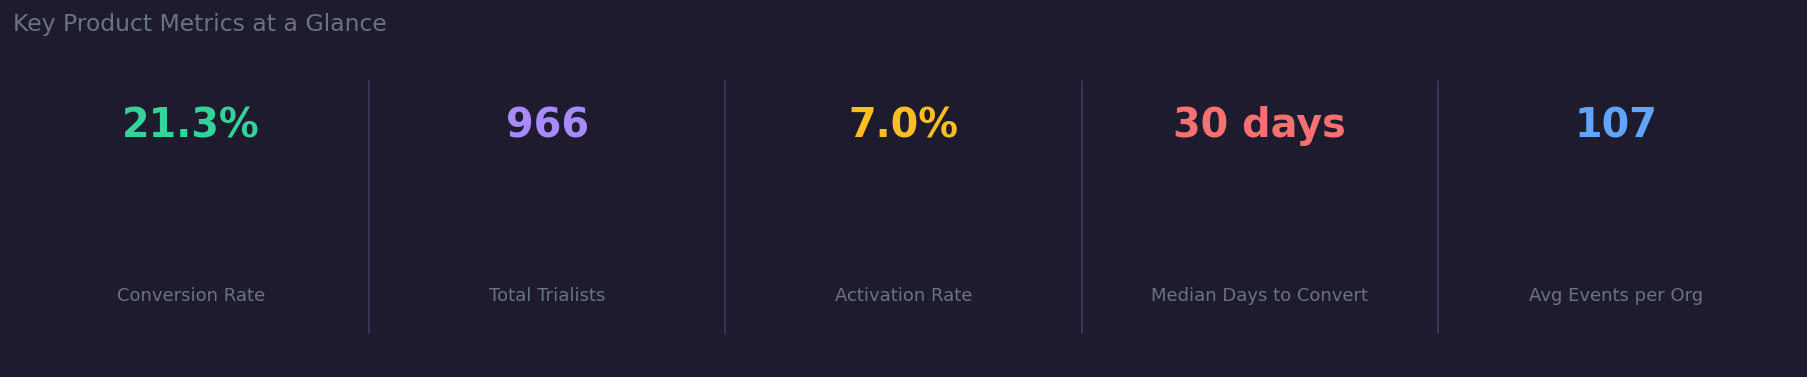

In [76]:
# Visualization : Core metrics dashboard

# KPI Scorecard
# Clear all existing plots first
plt.close("all")

fig, ax = plt.subplots(figsize=(14, 3), facecolor=DARK)
ax.set_facecolor(DARK)
ax.axis("off")

kpis = [
    ("Conversion Rate",      f"{conv_rate:.1f}%",              MINT),
    ("Total Trialists",      f"{total_orgs:,}",                LAVENDER),
    ("Activation Rate",      f"{activation_rate:.1f}%",        AMBER),
    ("Median Days to Convert", f"{ttc.median():.0f} days",     CORAL),
    ("Avg Events per Org",   f"{orgs['total_events'].mean():.0f}", "#60A5FA"),
]

for i, (label, value, color) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax.text(x, 0.72, value, ha="center", fontsize=22,
            fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(x, 0.2,  label, ha="center", fontsize=10,
            color=GRAY, transform=ax.transAxes)
    if i < len(kpis) - 1:
        ax.axvline(0.2 * (i + 1), color="#3D3557",
                   linewidth=1, ymin=0.1, ymax=0.9)

ax.set_title("Key Product Metrics at a Glance",
             fontsize=13, color=GRAY, pad=10, loc="left")
plt.tight_layout()
plt.show()

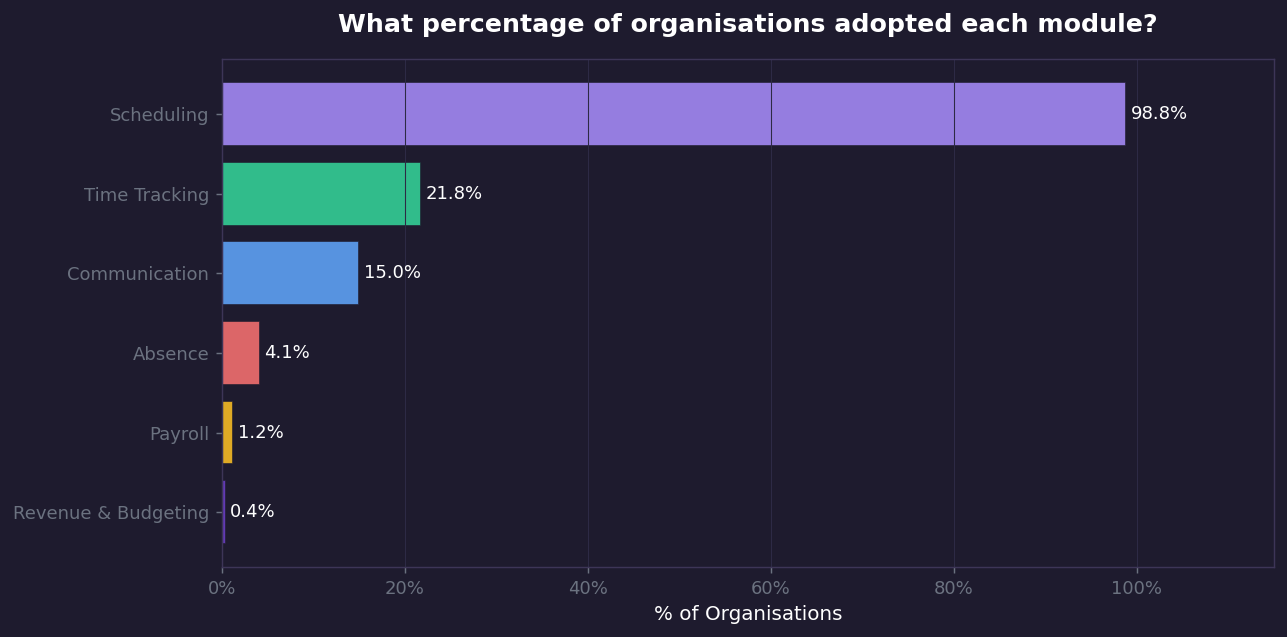

In [78]:
# Visualization : Feature adoption rate 
# What percentage of organisations adopted each module?

# Calculate adoption rate per module
module_adoption = (
    events.groupby("activity_category")["organization_id"]
    .nunique()
    .reset_index()
    .rename(columns={"organization_id": "n_orgs"})
)
module_adoption["adoption_rate_pct"] = (
    module_adoption["n_orgs"] / total_orgs * 100
).round(1)
module_adoption = module_adoption.sort_values("adoption_rate_pct", ascending=True)

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(DARK)

activity_colors = {
    "Scheduling":          LAVENDER,
    "Time Tracking":       MINT,
    "Payroll":             AMBER,
    "Absence":             CORAL,
    "Revenue & Budgeting": PURPLE,
    "Communication":       "#60A5FA",
}
colors = module_adoption["activity_category"].map(activity_colors)

bars = ax.barh(
    module_adoption["activity_category"],
    module_adoption["adoption_rate_pct"],
    color=colors, edgecolor=DARK, alpha=0.88
)

for bar, v in zip(bars, module_adoption["adoption_rate_pct"]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va="center", fontsize=10, color="white")

ax.set_title("What percentage of organisations adopted each module?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("% of Organisations", fontsize=11)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

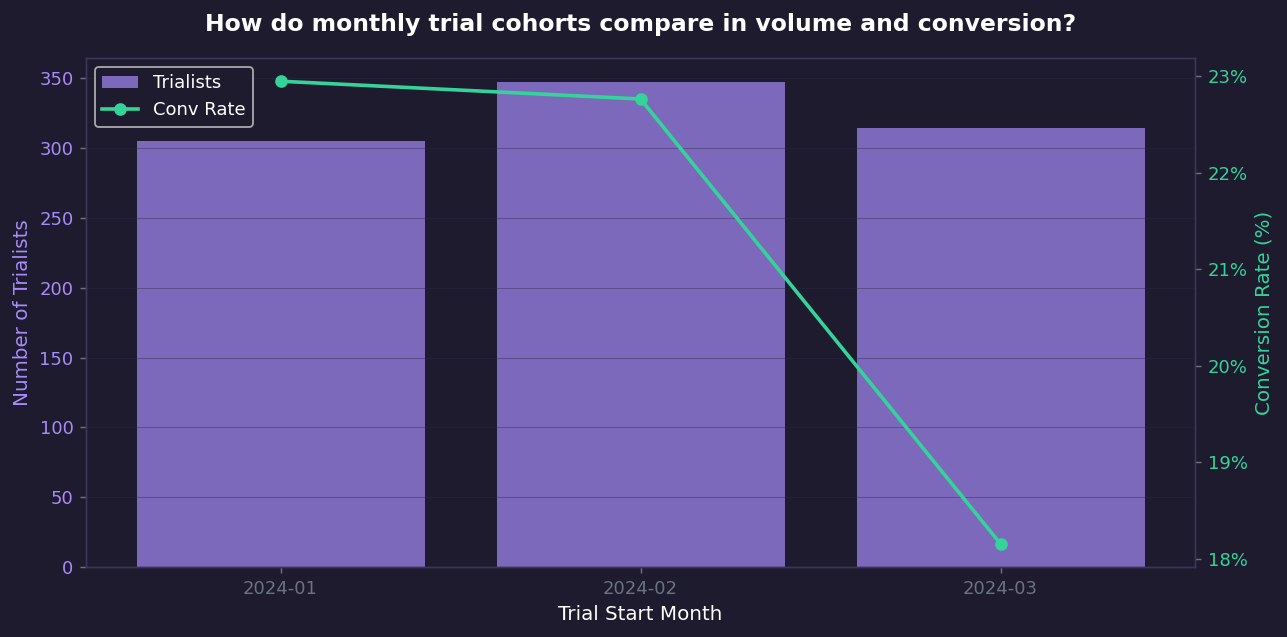

In [79]:
# Monthly cohort performance

# ── Fig 5: How do trial cohorts compare month by month? ──────────────────────
events["trial_month"] = pd.to_datetime(
    events["trial_start"]).dt.to_period("M").astype(str)

monthly = (
    events.drop_duplicates("organization_id")
    .groupby("trial_month")
    .agg(
        n_orgs      = ("organization_id", "count"),
        conv_rate   = ("converted",       "mean")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax1.set_facecolor(DARK)
ax2 = ax1.twinx()
ax2.set_facecolor(DARK)

ax1.bar(monthly["trial_month"], monthly["n_orgs"],
        color=LAVENDER, alpha=0.7, label="Trialists")
ax2.plot(monthly["trial_month"], monthly["conv_rate"] * 100,
         color=MINT, marker="o", linewidth=2, label="Conv Rate")

ax1.set_title("How do monthly trial cohorts compare in volume and conversion?",
              fontsize=13, fontweight="bold", color="white", pad=15)
ax1.set_xlabel("Trial Start Month", fontsize=11)
ax1.set_ylabel("Number of Trialists", color=LAVENDER, fontsize=11)
ax2.set_ylabel("Conversion Rate (%)", color=MINT,    fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.tick_params(axis="y", labelcolor=LAVENDER)
ax2.tick_params(axis="y", labelcolor=MINT)
ax1.grid(True, axis="y", alpha=0.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

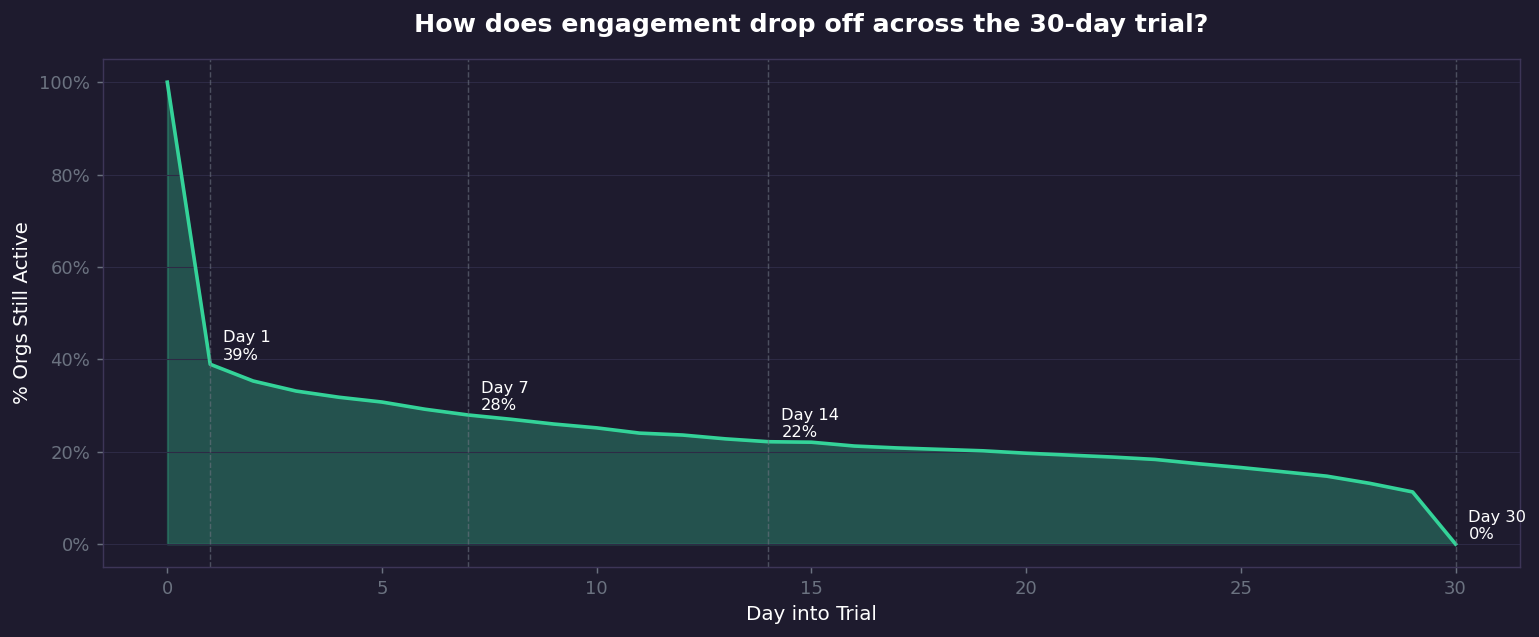

In [80]:
# ── How does engagement drop off across the 30-day trial? ────────────────────

retention = []
for d in range(0, 31):
    n = events[events["days_from_start"] >= d]["organization_id"].nunique()
    retention.append({"day": d, "pct_active": n / total_orgs * 100})

retention_df = pd.DataFrame(retention)

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK)
ax.set_facecolor(DARK)

ax.fill_between(retention_df["day"], retention_df["pct_active"],
                alpha=0.3, color=MINT)
ax.plot(retention_df["day"], retention_df["pct_active"],
        color=MINT, linewidth=2)

# Annotate key drop-off points
for day in [1, 7, 14, 30]:
    val = retention_df[retention_df["day"] == day]["pct_active"].values[0]
    ax.axvline(day, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(day + 0.3, val + 1, f"Day {day}\n{val:.0f}%",
            fontsize=9, color="white")

ax.set_title("How does engagement drop off across the 30-day trial?",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.set_xlabel("Day into Trial",        fontsize=11)
ax.set_ylabel("% Orgs Still Active",   fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

### Actionable recommendations

1. INTERVENE EARLY

   
   Only 39% of organizations have any activity after Day 1.
   An automated Day-2 nudge targeting inactive organizations
   could significantly improve trial engagement.

3. FOCUS ON SCHEDULING DEPTH


   Scheduling is the most adopted module (88% of organizations)
   and the strongest engagement signal. Onboarding should
   guide organizations to create their first 3 shifts quickly.

5. PUSH PUNCHCLOCK ADOPTION


   Only 22% of organizations used the PunchClock despite it being
   a core value driver. A dedicated onboarding step for
   time tracking could improve activation rates.

7. REVISIT THE ACTIVATION DEFINITION


   Fully activated organizations (all 5 goals) have the LOWEST
   conversion rate at 16.2%. Consider a 3-goal threshold
   as a more predictive activation benchmark.

9. TARGET HIGH-INTENT NON-CONVERTERS


   Organizations that completed 3+ goals but did not convert are
   strong candidates for direct sales outreach — they
   experienced product value but did not commit.

11. ADD A TRIAL-ENDING PROMPT


    Median conversion happens at Day 30 (trial expiry).
   A Day-25 prompt reminding organizations of trial expiry could
   accelerate conversion decisions.